In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import pickle
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 5)
sns.set_style("darkgrid")

print("Librerías cargadas")

Librerías cargadas


In [5]:
# montamos Google Drive
from google.colab import drive
drive.mount('/content/drive')

# ruta al CSV según lo que acordamos
RUTA_CSV = '/content/drive/MyDrive/trading_bot/data/datos_ohlc_US500.csv'

# cargamos el CSV. solo tiene OHLCV, y calculamos los indicadores
df = pd.read_csv(RUTA_CSV)
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time').reset_index(drop=True)

print(f"CSV cargado correctamente")
print(f"   Filas    : {len(df):,}")
print(f"   Columnas : {list(df.columns)}")
print(f"   Desde    : {df['time'].min()}")
print(f"   Hasta    : {df['time'].max()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CSV cargado correctamente
   Filas    : 77,691
   Columnas : ['time', 'open', 'high', 'low', 'close']
   Desde    : 2023-03-20 14:30:00
   Hasta    : 2026-07-03 19:45:00


In [6]:



# ESTRATEGIA BASE de FÉLIX

# períodos del canal Donchian
# períodos de la media móvil de tendencia
# períodos del CCI
# períodos del ATR
# CCI mínimo para confirmar momentum alcista
# stop loss = SL_MULT × ATR
# take profit = TP_MULT × ATR
# velas máximas para esperar TP o SL

DONCHIAN_PERIODO  = 20
SMA_PERIODO       = 200
CCI_PERIODO       = 14
ATR_PERIODO       = 14
CCI_UMBRAL        = 100
SL_MULT           = 1.5
TP_MULT           = 2.0
LOOKAHEAD_VELAS   = 30

# MODELO DE ML
# probabilidad mínima para ejecutar la operación
UMBRAL_ML         = 0.50

#  DIVISIÓN TEMPORAL
# Entrenamiento: marzo 2023 / septiembre 2025
# Backtesting:   octubre 2025 / diciembre 2025
# Forward:       enero 2026 / julio 2026
FECHA_FIN_ENTRENAMIENTO = '2025-09-30'
FECHA_FIN_BACKTEST      = '2025-12-31'
# Forward = todo lo que queda después de FECHA_FIN_BACKTEST



# GESTOR DE RIESGO (GetLeveraged Turbo Trade)

# balance inicial siempre en USD
# objetivo: 6% = $600
# limite de perdida diaria: 3% → $300
# drawdown (limite de perdida total: 6% trailing
# consistencia exigida: ningún día > 20% de ganancias totales
# paramos al 50% del límite diario
# 8 velas M15

BALANCE_INICIAL    = 10_000
OBJETIVO_PCT       = 0.06
LIMITE_DIARIO_PCT  = 0.03
DRAWDOWN_PCT       = 0.06
CONSISTENCIA_MAX   = 0.20
STOP_BUFFER_PCT    = 0.50
TIEMPO_MIN_VELAS   = 8
# escalado de lotes según proximidad al piso del drawdown
# formato: (ratio_mínimo_del_margen, tamaño_de_lote)
# ratio = (balance - piso_drawdown) / (equity_max * drawdown_pct)
LOTES_ESCALA = [
    (0.95, 0.5),
    (0.90, 0.4),
    (0.85, 0.3),
    (0.80, 0.2),
    (0.75, 0.1),
    (0.00, 0.0),
]

# stop buffer calculado
STOP_BUFFER_DIARIO = BALANCE_INICIAL * LIMITE_DIARIO_PCT * STOP_BUFFER_PCT

print("Parámetros cargados:")
print(f"   Estrategia  : Donchian({DONCHIAN_PERIODO}) + SMA({SMA_PERIODO}) + CCI({CCI_PERIODO})")
print(f"   SL/TP       : {SL_MULT}×ATR / {TP_MULT}×ATR  (ratio {TP_MULT/SL_MULT:.2f})")
print(f"   Umbral ML   : {UMBRAL_ML}")
print(f"   Balance     : ${BALANCE_INICIAL:,}")
print(f"   Objetivo    : ${BALANCE_INICIAL * OBJETIVO_PCT:,.0f} (+{OBJETIVO_PCT*100:.0f}%)")
print(f"   Stop buffer : ${STOP_BUFFER_DIARIO:,.0f}/día")

Parámetros cargados:
   Estrategia  : Donchian(20) + SMA(200) + CCI(14)
   SL/TP       : 1.5×ATR / 2.0×ATR  (ratio 1.33)
   Umbral ML   : 0.5
   Balance     : $10,000
   Objetivo    : $600 (+6%)
   Stop buffer : $150/día


In [7]:
# CORRECCIÓN vs NB1 de Félix:
# en NB1 se usó closed='left' para Donchian, lo que puede generar NaN adicionales.
# usamos shift(1) que es más limpio y estándar.
# =======

# SMA 200 (filtro de tendencia)
df['sma_200'] = df['close'].rolling(window=SMA_PERIODO).mean()

# CANAL DONCHIAN (señal de ruptura)
# shift(1) para que la vela actual no se incluya en el cálculo
# (evita look-ahead bias: no sabemos el máximo de la vela actualmhasta que cierra)
df['donchian_upper'] = df['high'].rolling(window=DONCHIAN_PERIODO).max().shift(1)
df['donchian_lower'] = df['low'].rolling(window=DONCHIAN_PERIODO).min().shift(1)

#  ATR  Average True Range (volatilidad para SL/TP)
# fórmula estándar de Wilder
high_low    = df['high'] - df['low']
high_close  = (df['high'] - df['close'].shift(1)).abs()
low_close   = (df['low']  - df['close'].shift(1)).abs()
true_range  = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
df['atr']   = true_range.ewm(alpha=1/ATR_PERIODO, adjust=False).mean()
# Nota: usamos EWM (media exponencial) que es el ATR de Wilder original.
# primero se usó rolling mean simple, ambos son válidos, EWM es más estándar

#  CCI Commodity Channel Index (confirmador de momentum)
tp          = (df['high'] + df['low'] + df['close']) / 3
sma_tp      = tp.rolling(window=CCI_PERIODO).mean()
mean_dev    = tp.rolling(window=CCI_PERIODO).apply(
                  lambda x: np.abs(x - x.mean()).mean(), raw=True)
df['cci']   = (tp - sma_tp) / (0.015 * mean_dev)

#  FEATURES RELATIVAS (corrección del primer modelo)
# NO usamos precios absolutos como features
# usamos distancias relativas al precio actual (sin unidad de precio)
# esto hace que el modelo generalice a cualquier nivel de precio.
df['dist_donchian_upper'] = (df['donchian_upper'] - df['close']) / df['close']
df['dist_donchian_lower'] = (df['close'] - df['donchian_lower']) / df['close']
df['dist_sma_200']        = (df['close'] - df['sma_200'])        / df['sma_200']
df['atr_relativo']        = df['atr'] / df['close']  # ATR como % del precio

#  LIMPIEZA de NaN generados por los indicadores
filas_antes = len(df)
df = df.dropna().reset_index(drop=True)
print(f" Indicadores calculados")
print(f"   Filas eliminadas por NaN: {filas_antes - len(df)}")
print(f"   Filas restantes         : {len(df):,}")
print(f"   Período limpio          : {df['time'].min().date()} → {df['time'].max().date()}")


 Indicadores calculados
   Filas eliminadas por NaN: 199
   Filas restantes         : 77,492
   Período limpio          : 2023-03-22 → 2026-07-03


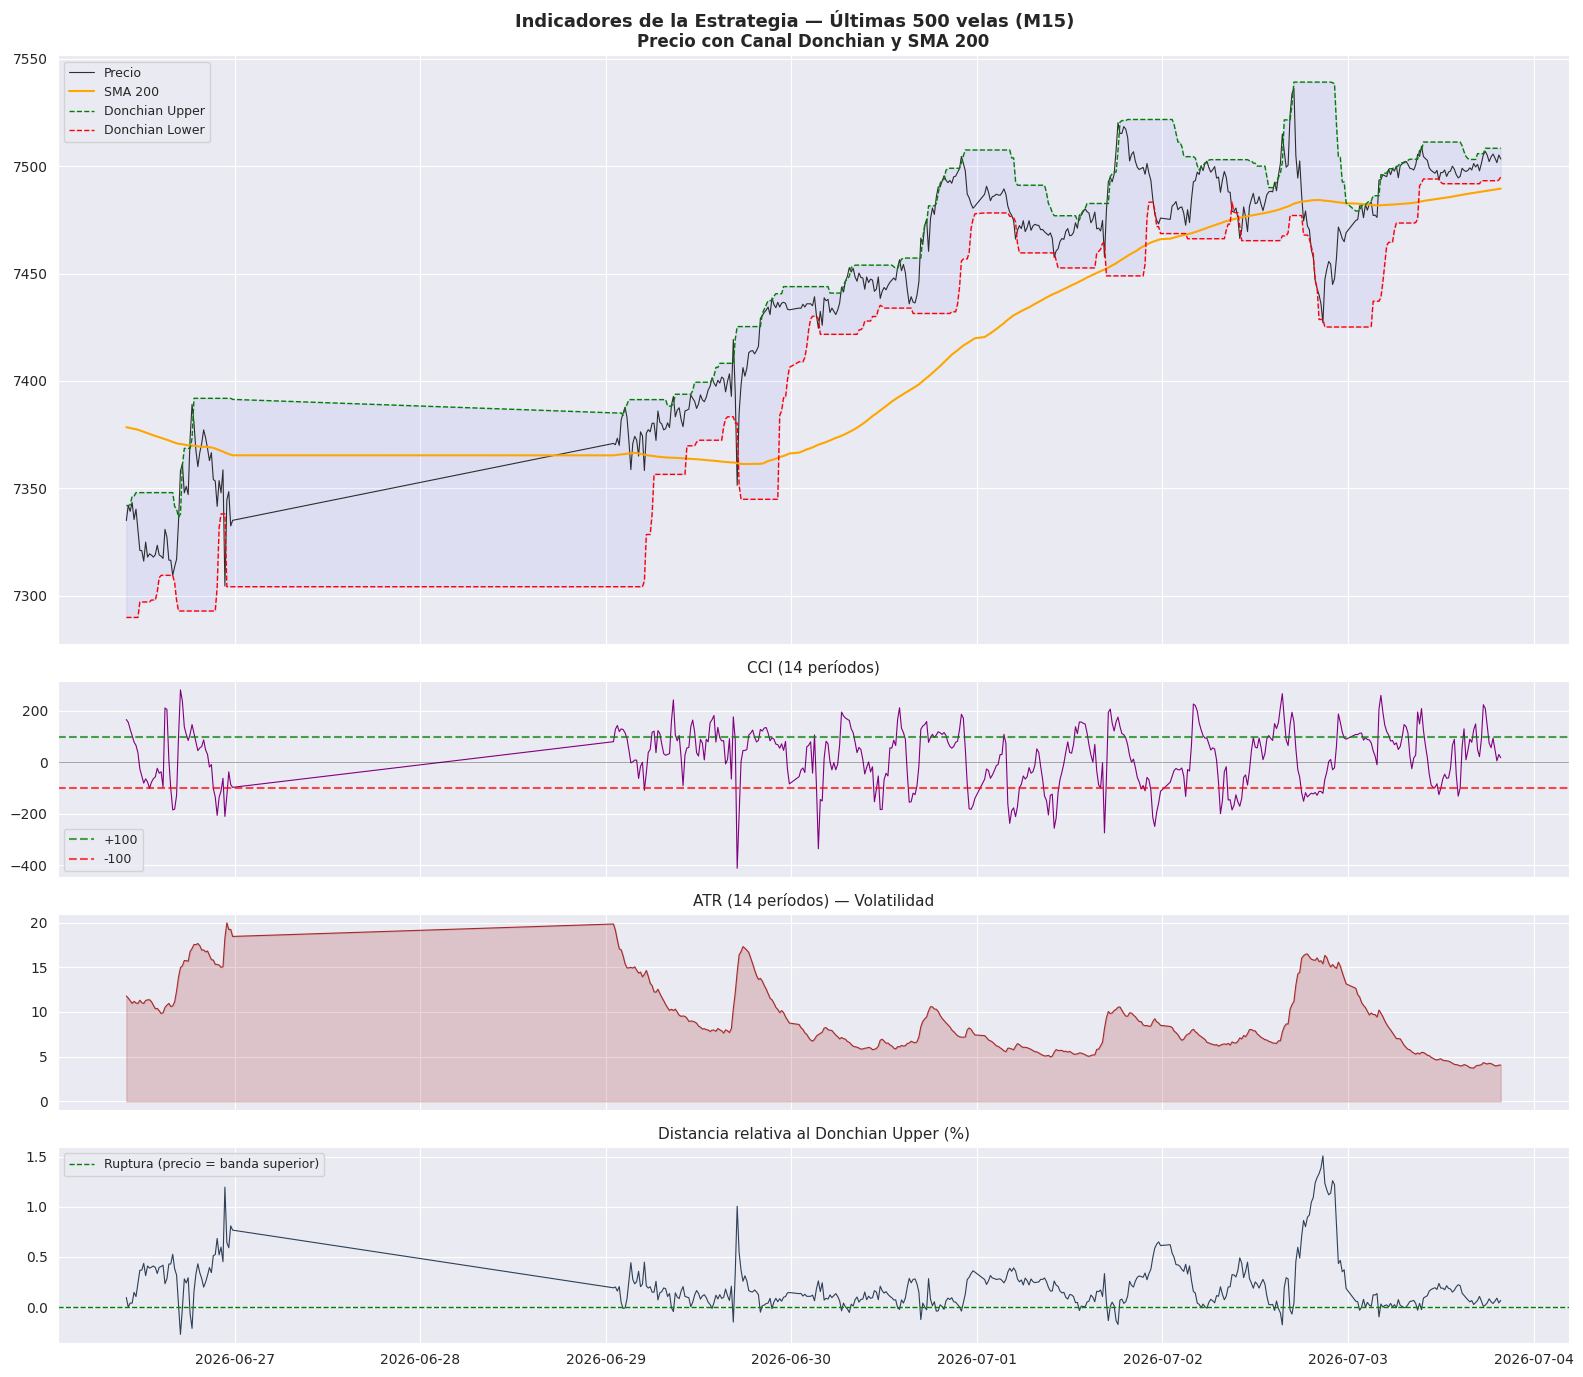

In [8]:
df_muestra = df.tail(500).copy()

fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1, 1, 1]})

# precio + Donchian + SMA200
axes[0].plot(df_muestra['time'], df_muestra['close'],
             color='black', linewidth=0.8, alpha=0.8, label='Precio')
axes[0].plot(df_muestra['time'], df_muestra['sma_200'],
             color='orange', linewidth=1.5, label=f'SMA {SMA_PERIODO}')
axes[0].plot(df_muestra['time'], df_muestra['donchian_upper'],
             color='green', linewidth=1.0, linestyle='--', label='Donchian Upper')
axes[0].plot(df_muestra['time'], df_muestra['donchian_lower'],
             color='red', linewidth=1.0, linestyle='--', label='Donchian Lower')
axes[0].fill_between(df_muestra['time'],
                     df_muestra['donchian_upper'],
                     df_muestra['donchian_lower'],
                     alpha=0.05, color='blue')
axes[0].set_title('Precio con Canal Donchian y SMA 200', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)

# CCI
axes[1].plot(df_muestra['time'], df_muestra['cci'], color='purple', linewidth=0.8)
axes[1].axhline(CCI_UMBRAL,  color='green', linestyle='--', alpha=0.7, label=f'+{CCI_UMBRAL}')
axes[1].axhline(-CCI_UMBRAL, color='red',   linestyle='--', alpha=0.7, label=f'-{CCI_UMBRAL}')
axes[1].axhline(0, color='black', linewidth=0.5, alpha=0.5)
axes[1].set_title(f'CCI ({CCI_PERIODO} períodos)', fontsize=11)
axes[1].legend(fontsize=9)

# ATR
axes[2].plot(df_muestra['time'], df_muestra['atr'], color='brown', linewidth=0.8)
axes[2].fill_between(df_muestra['time'], df_muestra['atr'],
                     alpha=0.2, color='brown')
axes[2].set_title(f'ATR ({ATR_PERIODO} períodos) — Volatilidad', fontsize=11)

# distancia relativa al Donchian Upper (la más importante para la señal)
axes[3].plot(df_muestra['time'], df_muestra['dist_donchian_upper'] * 100,
             color='#2E4057', linewidth=0.8)
axes[3].axhline(0, color='green', linewidth=1.0, linestyle='--',
                label='Ruptura (precio = banda superior)')
axes[3].set_title('Distancia relativa al Donchian Upper (%)', fontsize=11)
axes[3].legend(fontsize=9)

plt.suptitle('Indicadores de la Estrategia — Últimas 500 velas (M15)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# Para cada vela i, simulamos una operación de compra:
#    Entrada al precio de cierre de la vela i
#    TP = close + ATR × TP_MULT
#    SL = close - ATR × SL_MULT
#    Miramos las siguientes LOOKAHEAD_VELAS velas
#    Si el máximo de alguna vela toca el TP → etiqueta = 1
#    Si el mínimo de alguna vela toca el SL → etiqueta = 0
#    Si no pasa nada en LOOKAHEAD_VELAS velas → etiqueta = 0
#
# primera CORRECCIÓN vs base: eliminamos la segunda función duplicada
# y la columna 'senal_compra = 1' que era un parche temporal.
# Etiquetamos TODAS las velas (el modelo aprende a distinguir
# cuándo una entrada sería buena, independientemente de si
# cumple las condiciones Donchian/CCI).


print(" Calculando etiquetas ...")

cerrar = df['close'].values
maximos = df['high'].values
minimos = df['low'].values
atrs    = df['atr'].values
n       = len(df)

etiquetas = np.zeros(n, dtype=int)

for i in range(n - LOOKAHEAD_VELAS):
    precio_entrada = cerrar[i]
    atr_entrada    = atrs[i]

    nivel_tp = precio_entrada + atr_entrada * TP_MULT
    nivel_sl = precio_entrada - atr_entrada * SL_MULT

    # Recorremos las velas futuras buscando cuál se toca primero
    for j in range(i + 1, i + LOOKAHEAD_VELAS + 1):
        if maximos[j] >= nivel_tp:
            etiquetas[i] = 1   # TP tocado → ganancia
            break
        if minimos[j] <= nivel_sl:
            etiquetas[i] = 0   # SL tocado → pérdida
            break
        # Si no tocó ninguno, queda en 0 (pérdida/no concluyente)

df['etiqueta'] = etiquetas

# Análisis del balance de clases
conteo = df['etiqueta'].value_counts()
total  = len(df)
pct_1  = conteo.get(1, 0) / total * 100
pct_0  = conteo.get(0, 0) / total * 100

print(f" Etiquetado completado")
print(f"   Etiqueta 1 (TP tocado primero): {conteo.get(1,0):,} ({pct_1:.1f}%)")
print(f"   Etiqueta 0 (SL tocado primero): {conteo.get(0,0):,} ({pct_0:.1f}%)")
print()

if pct_1 < 30 or pct_1 > 70:
    print("⚠️  AVISO: distribución desbalanceada.")
    print(f"   Con SL={SL_MULT}×ATR y TP={TP_MULT}×ATR, el {pct_1:.1f}% son ganadoras.")
    print("   Si el % es muy bajo, el modelo va a predecir siempre 0.")
    print("   Considerá ajustar SL_MULT o TP_MULT en la Celda 4.")
else:
    print(f"Balance aceptable: {pct_1:.1f}% ganadoras / {pct_0:.1f}% perdedoras")

 Calculando etiquetas ...
 Etiquetado completado
   Etiqueta 1 (TP tocado primero): 30,034 (38.8%)
   Etiqueta 0 (SL tocado primero): 47,458 (61.2%)

Balance aceptable: 38.8% ganadoras / 61.2% perdedoras


In [10]:
# primera CORRECCIÓN vs base: usamos distancias relativas, no precios.
# El modelo no debe aprender "cuando el precio es 4000 es bueno"
# sino "cuando el precio está 0.5% por encima de la SMA200 es bueno"


FEATURES = [
    'cci',                  # Momentum (oscilador)
    'dist_donchian_upper',  # Distancia relativa a la banda superior
    'dist_donchian_lower',  # Distancia relativa a la banda inferior
    'dist_sma_200',         # Posición relativa respecto a la tendencia
    'atr_relativo',         # Volatilidad relativa al precio
]

# verificamos que todas existan
faltantes = [f for f in FEATURES if f not in df.columns]
if faltantes:
    print(f" Features faltantes: {faltantes}")
else:
    print(f" Features confirmadas: {FEATURES}")

# Guardamos para referencia
with open('features.json', 'w') as f:
    json.dump(FEATURES, f)

 Features confirmadas: ['cci', 'dist_donchian_upper', 'dist_donchian_lower', 'dist_sma_200', 'atr_relativo']


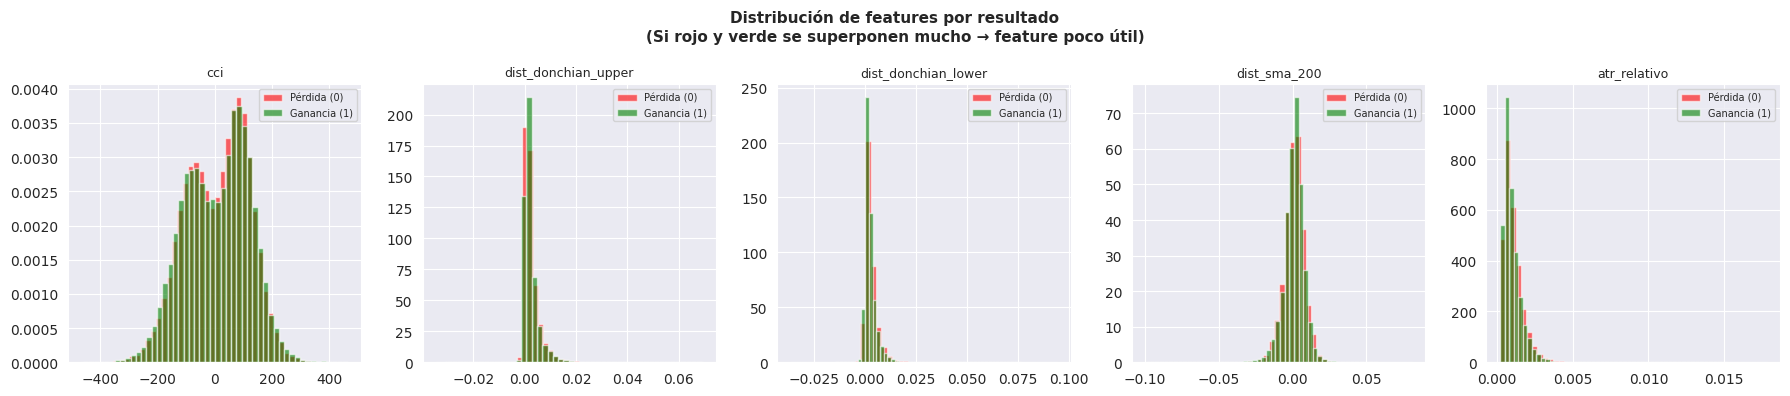


📌 Correlación de cada feature con la etiqueta:
  dist_sma_200              +0.0016  
  cci                       -0.0062  
  dist_donchian_upper       -0.0365  █
  dist_donchian_lower       -0.0558  ██
  atr_relativo              -0.0647  ███


In [11]:

# Análisis de poder predictivo de cada feature


fig, axes = plt.subplots(1, len(FEATURES), figsize=(18, 4))

for i, feat in enumerate(FEATURES):
    # Comparamos la distribución de cada feature según la etiqueta
    df[df['etiqueta'] == 0][feat].hist(
        bins=50, ax=axes[i], alpha=0.6, color='red',
        label='Pérdida (0)', density=True)
    df[df['etiqueta'] == 1][feat].hist(
        bins=50, ax=axes[i], alpha=0.6, color='green',
        label='Ganancia (1)', density=True)
    axes[i].set_title(feat, fontsize=9)
    axes[i].legend(fontsize=7)

plt.suptitle('Distribución de features por resultado\n'
             '(Si rojo y verde se superponen mucho → feature poco útil)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlación de cada feature con la etiqueta
print("\n📌 Correlación de cada feature con la etiqueta:")
corr = df[FEATURES + ['etiqueta']].corr()['etiqueta'].drop('etiqueta').sort_values(ascending=False)
for feat, val in corr.items():
    barra = '█' * int(abs(val) * 50)
    signo = '+' if val >= 0 else '-'
    print(f"  {feat:<25} {signo}{abs(val):.4f}  {barra}")

=== DIVISIÓN TEMPORAL ===
📘 Entrenamiento  : 59,560 velas | 2023-03-22 → 2025-09-29
📙 Backtesting    :  5,899 velas | 2025-09-30 → 2025-12-30
📗 Forward Testing: 12,033 velas | 2025-12-31 → 2026-07-03


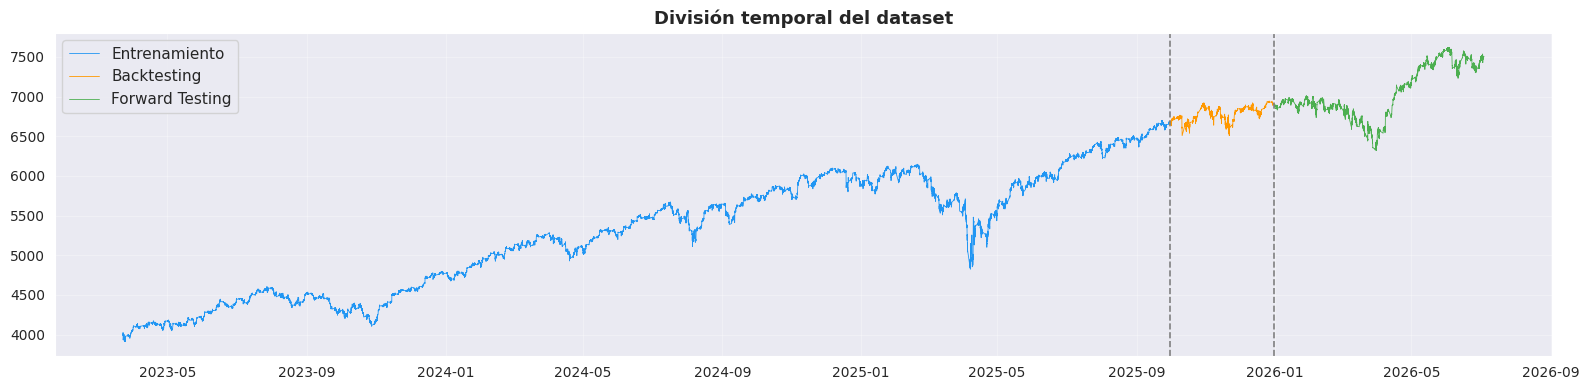

In [12]:

#  División temporal


df_train = df[df['time'] <= FECHA_FIN_ENTRENAMIENTO].copy()
df_bt    = df[(df['time'] > FECHA_FIN_ENTRENAMIENTO) &
              (df['time'] <= FECHA_FIN_BACKTEST)].copy()
df_fw    = df[df['time'] > FECHA_FIN_BACKTEST].copy()

print("=== DIVISIÓN TEMPORAL ===")
print(f"📘 Entrenamiento  : {len(df_train):>6,} velas | "
      f"{df_train['time'].min().date()} → {df_train['time'].max().date()}")
print(f"📙 Backtesting    : {len(df_bt):>6,} velas | "
      f"{df_bt['time'].min().date()} → {df_bt['time'].max().date()}")
print(f"📗 Forward Testing: {len(df_fw):>6,} velas | "
      f"{df_fw['time'].min().date()} → {df_fw['time'].max().date()}")

# Gráfico de división
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df_train['time'], df_train['close'], color='#2196F3', linewidth=0.6, label='Entrenamiento')
ax.plot(df_bt['time'],    df_bt['close'],    color='#FF9800', linewidth=0.6, label='Backtesting')
ax.plot(df_fw['time'],    df_fw['close'],    color='#4CAF50', linewidth=0.6, label='Forward Testing')
ax.axvline(pd.to_datetime(FECHA_FIN_ENTRENAMIENTO), color='gray', linestyle='--', linewidth=1.2)
ax.axvline(pd.to_datetime(FECHA_FIN_BACKTEST),      color='gray', linestyle='--', linewidth=1.2)
ax.set_title('División temporal del dataset', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

 Modelo entrenado: LogisticRegression
   Entrenado con 59,560 filas

=== EVALUACIÓN DEL MODELO (período de backtesting) ===
              precision    recall  f1-score   support

     Pérdida       0.67      0.41      0.51      3682
    Ganancia       0.41      0.66      0.50      2217

    accuracy                           0.51      5899
   macro avg       0.54      0.54      0.51      5899
weighted avg       0.57      0.51      0.51      5899

AUC-ROC: 0.5491
❌ Resultado pobre: revisar features o definición de etiqueta

 Peso de cada feature en el modelo:
  dist_donchian_lower       0.0744  ██
  dist_donchian_upper       0.0652  █
  atr_relativo              0.0637  █
  dist_sma_200              0.0239  
  cci                       0.0047  


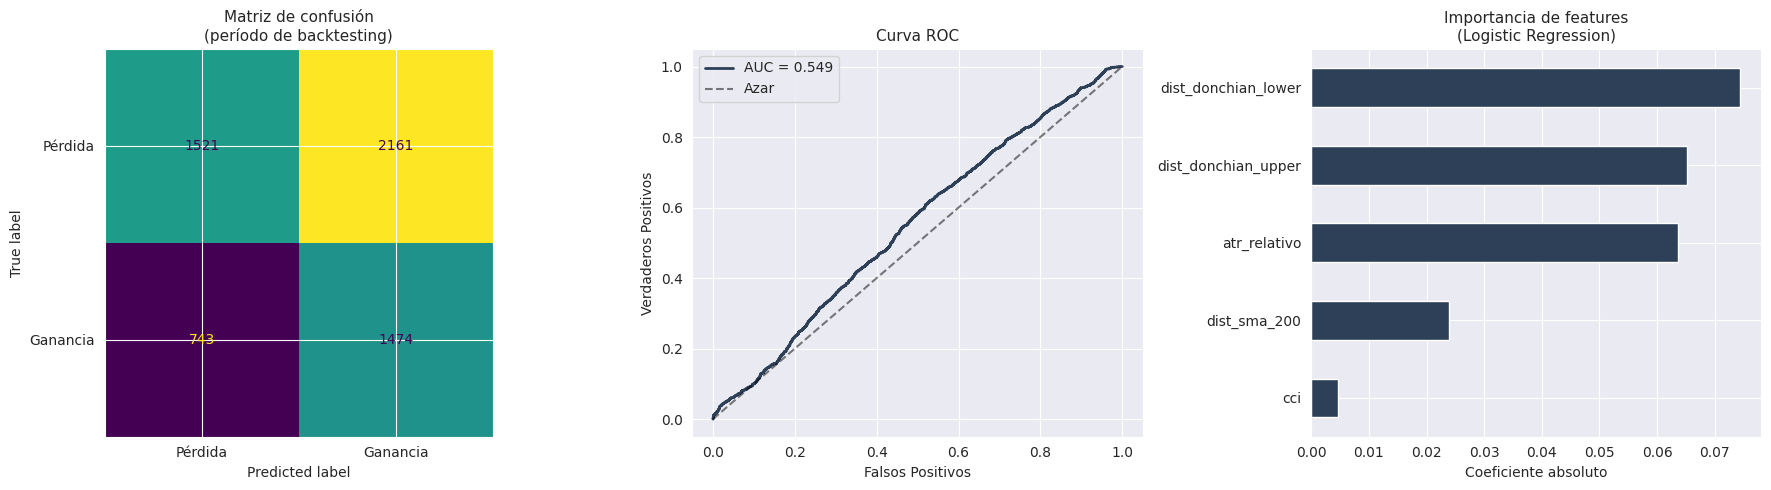


✅ modelo.pkl y scaler.pkl guardados


In [13]:

# Entrenamiento del modelo de ML
#
# primera CORRECCIÓN vs base:
# El scaler se entrena SOLO con df_train, no con el dataset completo.
# Esto es fundamental para evitar data leakage.


X_train = df_train[FEATURES]
y_train = df_train['etiqueta']

X_bt    = df_bt[FEATURES]
y_bt    = df_bt['etiqueta']

X_fw    = df_fw[FEATURES]
y_fw    = df_fw['etiqueta']

# Scaler entrenado SOLO con datos de entrenamiento
scaler = StandardScaler()
scaler.fit(X_train)   # Solo aprende la media y desvío de los datos de entrenamiento

X_train_sc = scaler.transform(X_train)
X_bt_sc    = scaler.transform(X_bt)
X_fw_sc    = scaler.transform(X_fw)

# Logistic Regression
modelo = LogisticRegression(
    C=1.0,
    max_iter=1000,
    random_state=42,
    class_weight='balanced'  # Compensa el desbalance de clases
)
modelo.fit(X_train_sc, y_train)

print(f" Modelo entrenado: {type(modelo).__name__}")
print(f"   Entrenado con {len(X_train_sc):,} filas")

# Evaluación sobre backtesting (conjunto de validación)
y_pred_bt   = modelo.predict(X_bt_sc)
y_prob_bt   = modelo.predict_proba(X_bt_sc)[:, 1]
auc_bt      = roc_auc_score(y_bt, y_prob_bt)

print(f"\n=== EVALUACIÓN DEL MODELO (período de backtesting) ===")
print(classification_report(y_bt, y_pred_bt, target_names=['Pérdida', 'Ganancia']))
print(f"AUC-ROC: {auc_bt:.4f}")

if auc_bt > 0.60:
    print("✅ Buen resultado: el modelo discrimina mejor que el azar")
elif auc_bt > 0.55:
    print("🟡 Aceptable: ligeramente mejor que el azar")
else:
    print("❌ Resultado pobre: revisar features o definición de etiqueta")

# Importancia de features
print("\n Peso de cada feature en el modelo:")
importancias = pd.Series(np.abs(modelo.coef_[0]), index=FEATURES).sort_values(ascending=False)
for feat, val in importancias.items():
    barra = '█' * int(val * 30)
    print(f"  {feat:<25} {val:.4f}  {barra}")

# Gráficos de evaluación
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Matriz de confusión
cm = confusion_matrix(y_bt, y_pred_bt)
ConfusionMatrixDisplay(cm, display_labels=['Pérdida', 'Ganancia']).plot(
    ax=axes[0], colorbar=False)
axes[0].set_title('Matriz de confusión\n(período de backtesting)', fontsize=11)

# Curva ROC
fpr, tpr, _ = roc_curve(y_bt, y_prob_bt)
axes[1].plot(fpr, tpr, color='#2E4057', linewidth=2, label=f'AUC = {auc_bt:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Azar')
axes[1].set_xlabel('Falsos Positivos')
axes[1].set_ylabel('Verdaderos Positivos')
axes[1].set_title('Curva ROC', fontsize=11)
axes[1].legend()

# Importancia de features
importancias.sort_values().plot(kind='barh', ax=axes[2], color='#2E4057')
axes[2].set_title('Importancia de features\n(Logistic Regression)', fontsize=11)
axes[2].set_xlabel('Coeficiente absoluto')

plt.tight_layout()
plt.show()

# Guardamos modelo y scaler
with open('modelo.pkl', 'wb') as f:
    pickle.dump(modelo, f)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("\n✅ modelo.pkl y scaler.pkl guardados")

In [14]:

#  Motor del backtesting (gestor de riesgo completo)


# priemra CORRECCIÓN vs estrategia base: la función estaba rota por el bug del
# docstring. Acá está completamente reescrita y funcional.
#
# La función implementa TODAS las reglas de GetLeveraged:
#   1. Drawdown trailing del 6%
#   2. Límite de pérdida diaria del 3%
#   3. Stop buffer diario (paramos al 50% del límite)
#   4. Regla de consistencia del 20%
#   5. Tiempo mínimo por operación (8 velas M15)
#   6. Escalado de lotes según proximidad al piso
#   7. Objetivo del 6% → la evaluación termina al alcanzarlo


def ejecutar_simulacion(df_periodo, modelo, scaler, features, params, nombre=""):
    """
    Simula el bot operando sobre df_periodo vela por vela.

    El modelo de ML evalúa cada vela y genera una probabilidad.
    Si prob >= UMBRAL_ML, el gestor de riesgo evalúa si se puede operar.
    Si se puede, se abre una operación y se cierra cuando toca TP, SL,
    o al alcanzar el tiempo máximo de LOOKAHEAD_VELAS velas.

    Retorna:
        pd.DataFrame con el registro de todas las operaciones
    """

    # Extraemos parámetros del diccionario
    balance_inicial    = params['BALANCE_INICIAL']
    objetivo_pct       = params['OBJETIVO_PCT']
    limite_diario_pct  = params['LIMITE_DIARIO_PCT']
    drawdown_pct       = params['DRAWDOWN_PCT']
    consistencia_max   = params['CONSISTENCIA_MAX']
    stop_buffer        = params['STOP_BUFFER_DIARIO']
    tiempo_min_velas   = params['TIEMPO_MIN_VELAS']
    umbral_ml          = params['UMBRAL_ML']
    lotes_escala       = params['LOTES_ESCALA']
    sl_mult            = params['SL_MULT']
    tp_mult            = params['TP_MULT']

    # Estado inicial del bot
    balance      = balance_inicial
    equity_max   = balance_inicial
    en_posicion  = False
    entrada_idx  = 0
    entrada_precio = 0.0
    nivel_tp     = 0.0
    nivel_sl     = 0.0
    lote_actual  = 0.0

    ganancia_total = 0.0
    perdida_dia    = 0.0
    ganancia_dia   = 0.0
    mejor_dia      = 0.0    # Para la regla de consistencia
    dia_actual     = None

    operaciones  = []
    bloqueadas   = 0   # Contador de señales bloqueadas por el gestor

    n = len(df_periodo)

    for i in range(n):
        vela   = df_periodo.iloc[i]
        fecha  = vela['time'].date()
        precio = vela['close']
        maximo = vela['high']
        minimo = vela['low']
        atr    = vela['atr']

        # Reset al cambiar de día
        if fecha != dia_actual:
            if dia_actual is not None and ganancia_dia > mejor_dia:
                mejor_dia = ganancia_dia
            dia_actual  = fecha
            perdida_dia = 0.0
            ganancia_dia = 0.0

        #  Actualizar equity máximo y piso del drawdown
        if balance > equity_max:
            equity_max = balance
        piso_drawdown = equity_max * (1 - drawdown_pct)

        #  Verificar límites globales

        # Drawdown excedido → fin de la simulación
        if balance <= piso_drawdown:
            if nombre:
                print(f" [{nombre}] DRAWDOWN EXCEDIDO en {fecha} | "
                      f"Balance: ${balance:.2f} | Piso: ${piso_drawdown:.2f}")
            break

        # Objetivo alcanzado → evaluación superada
        ganancia_acum = balance - balance_inicial
        if ganancia_acum >= balance_inicial * objetivo_pct:
            if nombre:
                print(f" [{nombre}] OBJETIVO ALCANZADO en {fecha} | "
                      f"Ganancia: ${ganancia_acum:.2f}")
            break

        #  Gestión de posición abierta
        if en_posicion:
            velas_en_trade = i - entrada_idx

            # TP tocado
            if maximo >= nivel_tp:
                pnl = (nivel_tp - entrada_precio) * lote_actual
                balance     += pnl
                ganancia_dia += pnl
                ganancia_total += pnl
                operaciones.append({
                    'fecha': str(fecha), 'entrada': round(entrada_precio, 2),
                    'salida': round(nivel_tp, 2), 'motivo': 'TP',
                    'pnl': round(pnl, 4), 'velas': velas_en_trade,
                    'lote': lote_actual, 'balance': round(balance, 2)
                })
                en_posicion = False
                continue

            # SL tocado
            if minimo <= nivel_sl:
                pnl = (nivel_sl - entrada_precio) * lote_actual
                balance    += pnl
                perdida_dia += abs(pnl)
                ganancia_total += pnl
                operaciones.append({
                    'fecha': str(fecha), 'entrada': round(entrada_precio, 2),
                    'salida': round(nivel_sl, 2), 'motivo': 'SL',
                    'pnl': round(pnl, 4), 'velas': velas_en_trade,
                    'lote': lote_actual, 'balance': round(balance, 2)
                })
                en_posicion = False
                continue

            # Tiempo máximo agotado → cierre en precio actual
            if velas_en_trade >= tiempo_min_velas * 4:  # 4× el mínimo como máximo
                pnl = (precio - entrada_precio) * lote_actual
                balance += pnl
                if pnl >= 0:
                    ganancia_dia   += pnl
                    ganancia_total += pnl
                else:
                    perdida_dia    += abs(pnl)
                    ganancia_total += pnl
                operaciones.append({
                    'fecha': str(fecha), 'entrada': round(entrada_precio, 2),
                    'salida': round(precio, 2), 'motivo': 'TIEMPO',
                    'pnl': round(pnl, 4), 'velas': velas_en_trade,
                    'lote': lote_actual, 'balance': round(balance, 2)
                })
                en_posicion = False
            continue

        #  Verificar si se puede operar

        # Stop buffer diario
        if perdida_dia >= stop_buffer:
            bloqueadas += 1
            continue

        # Regla de consistencia
        if ganancia_total > 0 and mejor_dia > 0:
            if ganancia_dia >= ganancia_total * consistencia_max:
                bloqueadas += 1
                continue

        # Escalado de lotes según margen disponible
        margen_disponible = balance - piso_drawdown
        margen_total      = equity_max * drawdown_pct
        ratio_margen      = margen_disponible / margen_total if margen_total > 0 else 0

        lote_actual = 0.0
        for (umbral_ratio, lote) in lotes_escala:
            if ratio_margen >= umbral_ratio:
                lote_actual = lote
                break

        if lote_actual == 0.0:
            bloqueadas += 1
            continue

        #  Señal del modelo de ML
        if not all(f in df_periodo.columns for f in features):
            continue

        X = df_periodo.iloc[i][features].values.reshape(1, -1)
        try:
            X_sc = scaler.transform(X)
            prob = modelo.predict_proba(X_sc)[0][1]
        except Exception:
            continue

        # Si la probabilidad no supera el umbral, descartamos
        if prob < umbral_ml:
            continue

        #  Abrir operación
        # Verificamos que el ATR sea válido
        if atr <= 0 or np.isnan(atr):
            continue

        en_posicion    = True
        entrada_precio = precio
        entrada_idx    = i
        nivel_tp       = precio + atr * tp_mult
        nivel_sl       = precio - atr * sl_mult

    return pd.DataFrame(operaciones), bloqueadas


# Diccionario de parámetros para pasarle a la función
PARAMS = {
    'BALANCE_INICIAL'   : BALANCE_INICIAL,
    'OBJETIVO_PCT'      : OBJETIVO_PCT,
    'LIMITE_DIARIO_PCT' : LIMITE_DIARIO_PCT,
    'DRAWDOWN_PCT'      : DRAWDOWN_PCT,
    'CONSISTENCIA_MAX'  : CONSISTENCIA_MAX,
    'STOP_BUFFER_DIARIO': STOP_BUFFER_DIARIO,
    'TIEMPO_MIN_VELAS'  : TIEMPO_MIN_VELAS,
    'UMBRAL_ML'         : UMBRAL_ML,
    'LOTES_ESCALA'      : LOTES_ESCALA,
    'SL_MULT'           : SL_MULT,
    'TP_MULT'           : TP_MULT,
}

print("✅ Motor de simulación definido")

✅ Motor de simulación definido


In [15]:
print(" Ejecutando backtesting...")
ops_bt, bloqueadas_bt = ejecutar_simulacion(
    df_bt, modelo, scaler, FEATURES, PARAMS, nombre="BACKTEST")

print(f"\n Backtesting completado")
print(f"   Operaciones ejecutadas : {len(ops_bt)}")
print(f"   Señales bloqueadas     : {bloqueadas_bt}")

if len(ops_bt) > 0:
    ganadas   = (ops_bt['pnl'] > 0).sum()
    perdidas  = (ops_bt['pnl'] <= 0).sum()
    winrate   = ganadas / len(ops_bt) * 100
    pnl_total = ops_bt['pnl'].sum()

    print(f"\n=== RESULTADOS BACKTEST (oct-dic 2025) ===")
    print(f"   Operaciones ganadas  : {ganadas} ({winrate:.1f}%)")
    print(f"   Operaciones perdidas : {perdidas}")
    print(f"   PnL total            : ${pnl_total:.2f}")
    print(f"   PnL promedio/op      : ${ops_bt['pnl'].mean():.2f}")
    print(f"   Mejor operación      : ${ops_bt['pnl'].max():.2f}")
    print(f"   Peor operación       : ${ops_bt['pnl'].min():.2f}")
    print(f"\n   Cierres por motivo:")
    print(ops_bt['motivo'].value_counts().to_string())
else:
    print("\n  Sin operaciones. Posibles causas:")
    print("   - UMBRAL_ML demasiado alto (bajalo a 0.50 en la Celda 4)")
    print("   - CCI_UMBRAL demasiado exigente")
    print("   - Pocas señales en el período de backtesting")

ops_bt.to_csv('resultados_backtest.csv', index=False)

 Ejecutando backtesting...

 Backtesting completado
   Operaciones ejecutadas : 221
   Señales bloqueadas     : 2317

=== RESULTADOS BACKTEST (oct-dic 2025) ===
   Operaciones ganadas  : 102 (46.2%)
   Operaciones perdidas : 119
   PnL total            : $9.05
   PnL promedio/op      : $0.04
   Mejor operación      : $9.39
   Peor operación       : $-7.56

   Cierres por motivo:
motivo
SL        114
TP         90
TIEMPO     17


In [16]:

#  Ejecutar Forward Testing


print(" Ejecutando forward testing...")
ops_fw, bloqueadas_fw = ejecutar_simulacion(
    df_fw, modelo, scaler, FEATURES, PARAMS, nombre="FORWARD")

print(f"\n Forward testing completado")
print(f"   Operaciones ejecutadas : {len(ops_fw)}")
print(f"   Señales bloqueadas     : {bloqueadas_fw}")

if len(ops_fw) > 0:
    ganadas   = (ops_fw['pnl'] > 0).sum()
    perdidas  = (ops_fw['pnl'] <= 0).sum()
    winrate   = ganadas / len(ops_fw) * 100
    pnl_total = ops_fw['pnl'].sum()

    print(f"\n=== RESULTADOS FORWARD (ene-jul 2026) ===")
    print(f"   Operaciones ganadas  : {ganadas} ({winrate:.1f}%)")
    print(f"   Operaciones perdidas : {perdidas}")
    print(f"   PnL total            : ${pnl_total:.2f}")
    print(f"   PnL promedio/op      : ${ops_fw['pnl'].mean():.2f}")
    print(f"\n   Cierres por motivo:")
    print(ops_fw['motivo'].value_counts().to_string())

ops_fw.to_csv('resultados_forward.csv', index=False)




 Ejecutando forward testing...

 Forward testing completado
   Operaciones ejecutadas : 333
   Señales bloqueadas     : 4675

=== RESULTADOS FORWARD (ene-jul 2026) ===
   Operaciones ganadas  : 150 (45.0%)
   Operaciones perdidas : 183
   PnL total            : $6.49
   PnL promedio/op      : $0.02

   Cierres por motivo:
motivo
SL        177
TP        137
TIEMPO     19



MÉTRICA                                  BACKTEST              FORWARD
Operaciones                                   221                  333
Winrate                                     46.2%                45.0%
PnL total                                   $9.05                $6.49
PnL promedio/op                             $0.04                $0.02
Sharpe ratio                                0.010                0.004
Profit factor                                1.02                 1.01
Max drawdown                              $-74.87              $-93.61


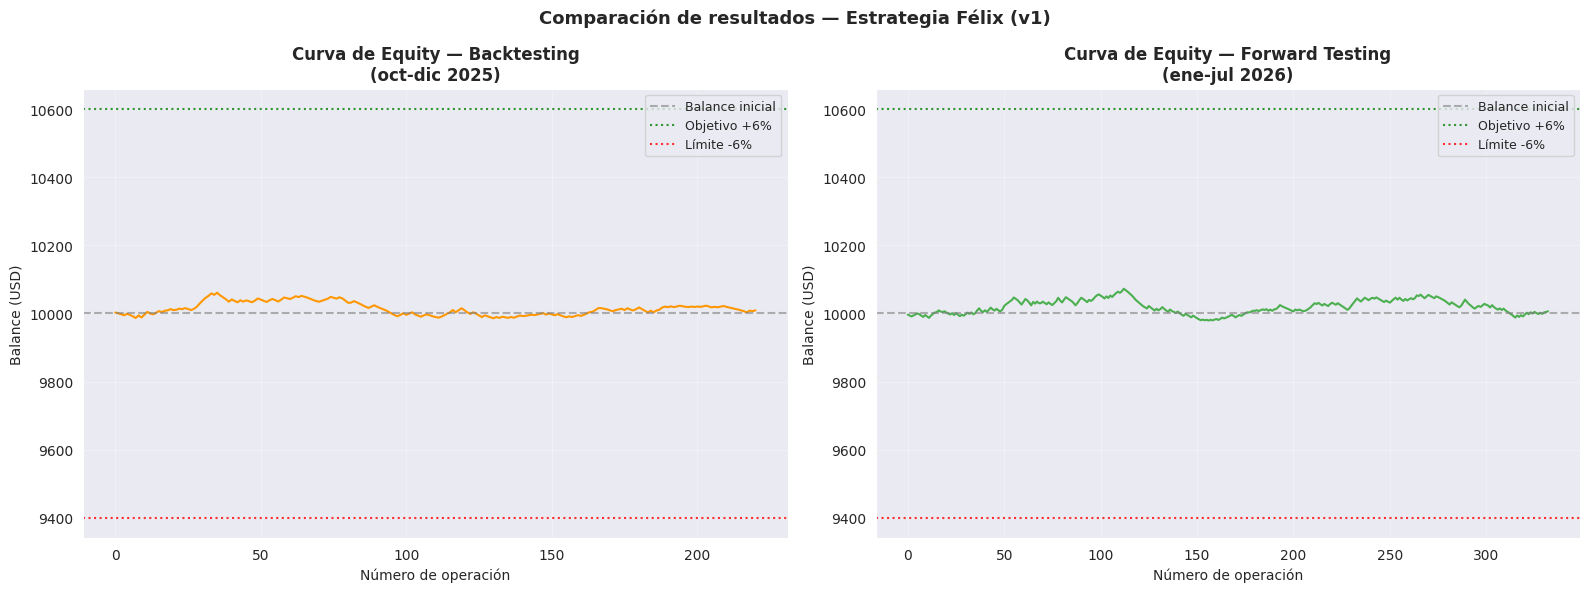


 Pipeline completo ejecutado.
   Archivos generados: resultados_backtest.csv, resultados_forward.csv
                       modelo.pkl, scaler.pkl, features.json

 PRÓXIMOS PASOS (barridos):
   → Ajustar SL_MULT y TP_MULT en la Celda 4 y volver a correr
   → Ajustar CCI_UMBRAL para filtrar más o menos señales
   → Ajustar UMBRAL_ML entre 0.50 y 0.65
   → Probar con DONCHIAN_PERIODO = 10, 15, 30


In [17]:

#  Métricas completas y visualizaciones finales

def calcular_metricas(df_ops, nombre, balance_inicial):
    if len(df_ops) == 0:
        print(f"  {nombre}: sin operaciones")
        return {}

    total      = len(df_ops)
    ganadas    = (df_ops['pnl'] > 0).sum()
    winrate    = ganadas / total * 100
    pnl_total  = df_ops['pnl'].sum()
    pnl_medio  = df_ops['pnl'].mean()
    pnl_std    = df_ops['pnl'].std()
    sharpe     = pnl_medio / pnl_std if pnl_std > 0 else 0

    ganancias  = df_ops[df_ops['pnl'] > 0]['pnl'].sum()
    perdidas   = abs(df_ops[df_ops['pnl'] < 0]['pnl'].sum())
    profit_factor = ganancias / perdidas if perdidas > 0 else float('inf')

    equity     = balance_inicial + df_ops['pnl'].cumsum()
    max_dd     = (equity - equity.cummax()).min()

    return {
        'nombre': nombre, 'total': total, 'winrate': winrate,
        'pnl_total': pnl_total, 'pnl_medio': pnl_medio,
        'sharpe': sharpe, 'profit_factor': profit_factor,
        'max_dd': max_dd, 'equity': equity
    }

m_bt = calcular_metricas(ops_bt, "Backtesting", BALANCE_INICIAL)
m_fw = calcular_metricas(ops_fw, "Forward Testing", BALANCE_INICIAL)

# Tabla comparativa
print("\n" + "="*70)
print(f"{'MÉTRICA':<28} {'BACKTEST':>20} {'FORWARD':>20}")
print("="*70)

if m_bt and m_fw:
    filas = [
        ("Operaciones",      f"{m_bt['total']}",                   f"{m_fw['total']}"),
        ("Winrate",          f"{m_bt['winrate']:.1f}%",            f"{m_fw['winrate']:.1f}%"),
        ("PnL total",        f"${m_bt['pnl_total']:.2f}",          f"${m_fw['pnl_total']:.2f}"),
        ("PnL promedio/op",  f"${m_bt['pnl_medio']:.2f}",          f"${m_fw['pnl_medio']:.2f}"),
        ("Sharpe ratio",     f"{m_bt['sharpe']:.3f}",              f"{m_fw['sharpe']:.3f}"),
        ("Profit factor",    f"{m_bt['profit_factor']:.2f}",       f"{m_fw['profit_factor']:.2f}"),
        ("Max drawdown",     f"${m_bt['max_dd']:.2f}",             f"${m_fw['max_dd']:.2f}"),
    ]
    for fila in filas:
        print(f"{fila[0]:<28} {fila[1]:>20} {fila[2]:>20}")

print("="*70)

# Curvas de equity
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, m, color, titulo, periodo in [
    (axes[0], m_bt, '#FF9800', 'Backtesting', 'oct-dic 2025'),
    (axes[1], m_fw, '#4CAF50', 'Forward Testing', 'ene-jul 2026')
]:
    if m and 'equity' in m:
        ax.plot(m['equity'].values, color=color, linewidth=1.5)
        ax.axhline(BALANCE_INICIAL,
                   color='gray', linestyle='--', alpha=0.6, label='Balance inicial')
        ax.axhline(BALANCE_INICIAL * (1 + OBJETIVO_PCT),
                   color='green', linestyle=':', alpha=0.8, label=f'Objetivo +{OBJETIVO_PCT*100:.0f}%')
        ax.axhline(BALANCE_INICIAL * (1 - DRAWDOWN_PCT),
                   color='red', linestyle=':', alpha=0.8, label=f'Límite -{DRAWDOWN_PCT*100:.0f}%')
        ax.set_title(f'Curva de Equity — {titulo}\n({periodo})',
                     fontsize=12, fontweight='bold')
        ax.set_xlabel('Número de operación')
        ax.set_ylabel('Balance (USD)')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'Sin operaciones', ha='center', va='center',
                fontsize=14, transform=ax.transAxes)
        ax.set_title(titulo)

plt.suptitle('Comparación de resultados — Estrategia Félix (v1)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n Pipeline completo ejecutado.")
print(f"   Archivos generados: resultados_backtest.csv, resultados_forward.csv")
print(f"                       modelo.pkl, scaler.pkl, features.json")
print()
print(" PRÓXIMOS PASOS (barridos):")
print("   → Ajustar SL_MULT y TP_MULT en la Celda 4 y volver a correr")
print("   → Ajustar CCI_UMBRAL para filtrar más o menos señales")
print("   → Ajustar UMBRAL_ML entre 0.50 y 0.65")
print("   → Probar con DONCHIAN_PERIODO = 10, 15, 30")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Dataset base cargado: 77,691 velas
   2023-03-20 → 2026-07-03
 Total de combinaciones a evaluar: 108
 Iniciando barrido...

  Progreso: 10/108 | Último: Donch=10 SL=1.0 TP=1.5 CCI=50
  Progreso: 40/99 | Último: Donch=20 SL=0.5 TP=2.0 CCI=50
  Progreso: 50/99 | Último: Donch=20 SL=1.0 TP=2.0 CCI=100
  Progreso: 60/96 | Último: Donch=20 SL=1.5 TP=2.0 CCI=150
  Progreso: 70/90 | Último: Donch=20 SL=2.0 TP=3.0 CCI=50
  Progreso: 80/90 | Último: Donch=30 SL=0.5 TP=3.0 CCI=100
  Progreso: 90/90 | Último: Donch=30 SL=1.0 TP=3.0 CCI=150

 Barrido completado: 81 combinaciones evaluadas

TOP 15 COMBINACIONES por Profit Factor combinado (BT + FW)
    donchian    sl    tp  ratio_tp_sl  cci_umb  wr_minimo  bt_ops  bt_wr  bt_pnl  bt_pf  fw_ops  fw_wr  fw_pnl  fw_pf  pf_combinado  pnl_combinado  consistencia
0         30 0.500 1.500        3.000      150     25.000      64

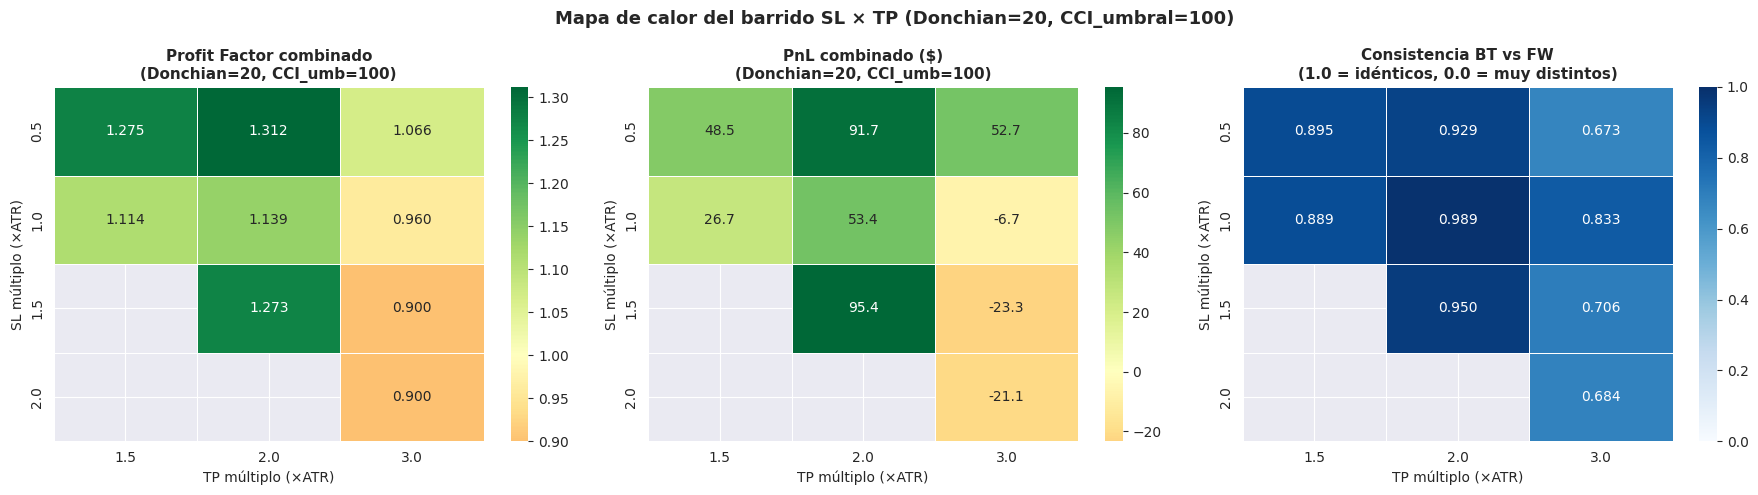

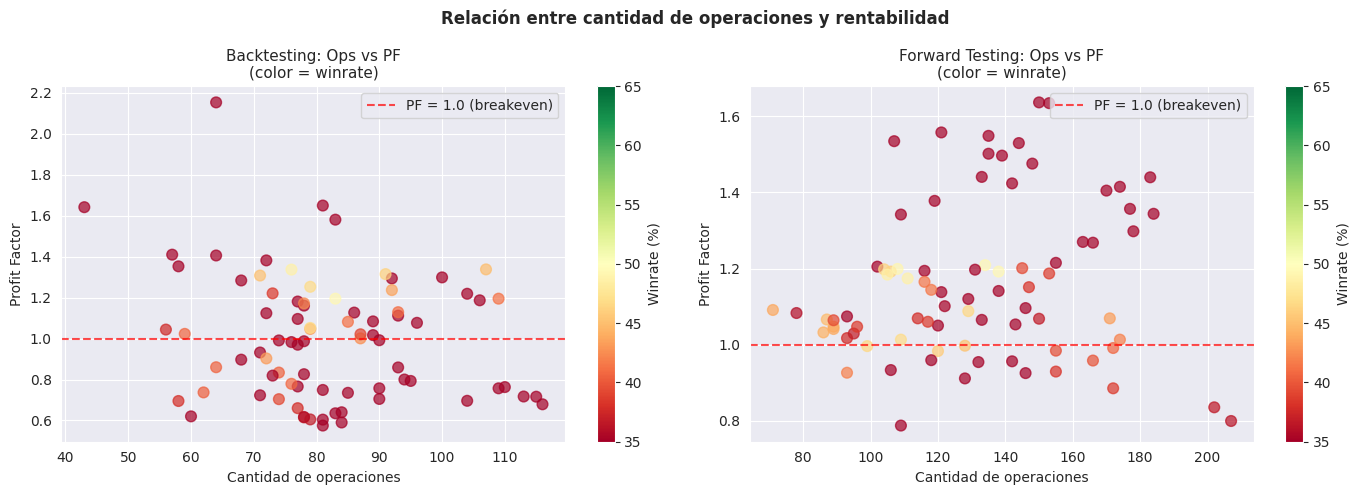

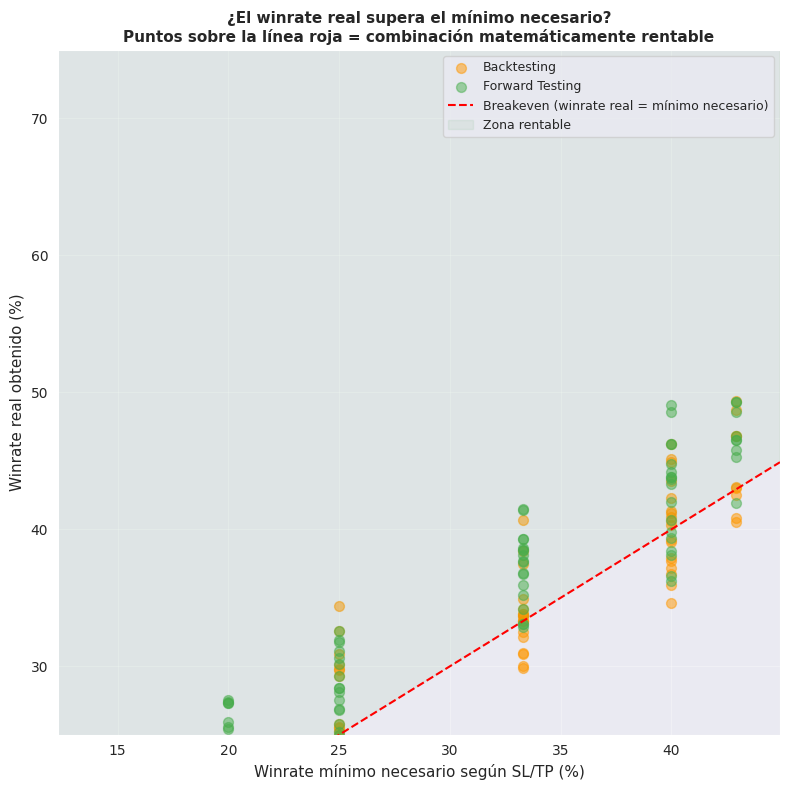


RESUMEN EJECUTIVO DEL BARRIDO

 MEJOR COMBINACIÓN ENCONTRADA:
   Donchian período : 30
   SL               : 0.5×ATR
   TP               : 1.5×ATR  (ratio 3.00)
   CCI umbral       : 150
   Winrate mínimo   : 25.0%
   BT → Ops: 64 | WR: 34.4% | PF: 2.154 | PnL: $64.04
   FW → Ops: 119 | WR: 31.1% | PF: 1.378 | PnL: $59.11
   PF combinado     : 1.766
   Consistencia     : 0.780

 DE 81 COMBINACIONES EVALUADAS:
   Rentables en BT solamente  : 40 (49.4%)
   Rentables en FW solamente  : 63 (77.8%)
   Rentables en AMBOS         : 31 (38.3%)

 Tabla completa guardada en: resultados_barrido.csv

 PRÓXIMOS PASOS:
   → Con la mejor combinación, ir al pipeline principal
     y cambiar SL_MULT, TP_MULT, DONCHIAN_PERIODO y CCI_UMBRAL
   → Si hay 0 combinaciones rentables en ambos períodos,
     la señal de Félix necesita ser revisada
   → Si hay rentabilidad en BT pero no en FW → overfitting


In [18]:

# BARRIDO DE PARÁMETROS — Estrategia Félix
#
#  este barrido evalúa:
#  Combinaciones de SL_MULT × TP_MULT (ratio riesgo/beneficio)
#  Períodos del canal Donchian (10, 15, 20, 30)
#  Umbral del CCI (50, 100, 150, 200)
#  Lookahead de velas para el etiquetado (15, 20, 30, 40)

# Al final genera una tabla ordenada por profit factor
# y un mapa de calor SL vs TP para ver la zona óptima


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings('ignore')

#  Necesitamos el df original con OHLCV limpio

from google.colab import drive
drive.mount('/content/drive', force_remount=False)

RUTA_CSV = '/content/drive/MyDrive/trading_bot/data/datos_ohlc_US500.csv'
df_base = pd.read_csv(RUTA_CSV)
df_base['time'] = pd.to_datetime(df_base['time'])
df_base = df_base.sort_values('time').reset_index(drop=True)

print(f" Dataset base cargado: {len(df_base):,} velas")
print(f"   {df_base['time'].min().date()} → {df_base['time'].max().date()}")




# FECHAS FIJAS  no cambian entre combinaciones


FECHA_FIN_TRAIN = '2025-09-30'
FECHA_FIN_BT    = '2025-12-31'
# Forward = todo lo que queda después de FECHA_FIN_BT

# Parámetros del gestor de riesgo (fijos en el barrido)
# Solo evaluamos la estrategia, no el gestor. Si el gestor
# bloquea todo, no vemos nada. Lo desactivamos parcialmente:
# el drawdown y objetivo siguen activos, pero con valores
# más amplios para no cortar el backtesting artificialmente.
BALANCE_INICIAL   = 10_000
OBJETIVO_PCT      = 0.06
DRAWDOWN_PCT      = 0.06
LIMITE_DIARIO_PCT = 0.03
STOP_BUFFER_PCT   = 0.50
CONSISTENCIA_MAX  = 0.20
TIEMPO_MIN_VELAS  = 8
UMBRAL_ML         = 0.50

LOTES_ESCALA = [
    (0.95, 0.5), (0.90, 0.4), (0.85, 0.3),
    (0.80, 0.2), (0.75, 0.1), (0.00, 0.0),
]



# FUNCIONES REUTILIZABLES


def calcular_indicadores(df, donchian_p, sma_p, cci_p, atr_p):
    """Calcula todos los indicadores sobre una copia del df."""
    d = df.copy()

    d['sma_200']        = d['close'].rolling(window=sma_p).mean()
    d['donchian_upper'] = d['high'].rolling(window=donchian_p).max().shift(1)
    d['donchian_lower'] = d['low'].rolling(window=donchian_p).min().shift(1)

    hl  = d['high'] - d['low']
    hc  = (d['high'] - d['close'].shift(1)).abs()
    lc  = (d['low']  - d['close'].shift(1)).abs()
    tr  = pd.concat([hl, hc, lc], axis=1).max(axis=1)
    d['atr'] = tr.ewm(alpha=1/atr_p, adjust=False).mean()

    tp_col   = (d['high'] + d['low'] + d['close']) / 3
    sma_tp   = tp_col.rolling(window=cci_p).mean()
    mean_dev = tp_col.rolling(window=cci_p).apply(
                   lambda x: np.abs(x - x.mean()).mean(), raw=True)
    d['cci'] = (tp_col - sma_tp) / (0.015 * mean_dev)

    # Features relativas (sin precios absolutos)
    d['dist_upper'] = (d['donchian_upper'] - d['close']) / d['close']
    d['dist_lower'] = (d['close'] - d['donchian_lower']) / d['close']
    d['dist_sma']   = (d['close'] - d['sma_200']) / d['sma_200']
    d['atr_rel']    = d['atr'] / d['close']

    d = d.dropna().reset_index(drop=True)
    return d


def calcular_etiquetas(df, sl_mult, tp_mult, lookahead):
    """Etiqueta cada vela según si el TP o SL se toca primero."""
    cerrar  = df['close'].values
    maximos = df['high'].values
    minimos = df['low'].values
    atrs    = df['atr'].values
    n       = len(df)
    etiq    = np.zeros(n, dtype=int)

    for i in range(n - lookahead):
        pe   = cerrar[i]
        atr  = atrs[i]
        ntp  = pe + atr * tp_mult
        nsl  = pe - atr * sl_mult
        for j in range(i + 1, i + lookahead + 1):
            if maximos[j] >= ntp:
                etiq[i] = 1
                break
            if minimos[j] <= nsl:
                break
    return etiq


FEATURES = ['cci', 'dist_upper', 'dist_lower', 'dist_sma', 'atr_rel']


def entrenar_modelo(df_train):
    """Entrena Logistic Regression y devuelve modelo + scaler."""
    X = df_train[FEATURES]
    y = df_train['etiqueta']
    sc = StandardScaler()
    sc.fit(X)
    X_sc = sc.transform(X)
    m = LogisticRegression(C=1.0, max_iter=1000, random_state=42,
                           class_weight='balanced')
    m.fit(X_sc, y)
    return m, sc


def simular(df_periodo, modelo, scaler, sl_mult, tp_mult,
            cci_umbral, umbral_ml):
    """
    Simula el bot sobre df_periodo con gestor de riesgo activo.
    Retorna métricas resumidas en un diccionario.
    """
    balance    = BALANCE_INICIAL
    equity_max = BALANCE_INICIAL
    piso_dd    = BALANCE_INICIAL * (1 - DRAWDOWN_PCT)

    en_pos      = False
    idx_entrada = 0
    p_entrada   = 0.0
    ntp = nsl   = 0.0
    lote        = 0.0

    gan_total = 0.0
    per_dia   = 0.0
    gan_dia   = 0.0
    mejor_dia = 0.0
    dia_act   = None
    stop_buf  = BALANCE_INICIAL * LIMITE_DIARIO_PCT * STOP_BUFFER_PCT

    ops       = []
    bloq      = 0

    n = len(df_periodo)

    for i in range(n):
        v      = df_periodo.iloc[i]
        fecha  = v['time'].date()
        precio = v['close']
        maximo = v['high']
        minimo = v['low']
        atr    = v['atr']

        # Reset diario
        if fecha != dia_act:
            if dia_act is not None and gan_dia > mejor_dia:
                mejor_dia = gan_dia
            dia_act = fecha
            per_dia = 0.0
            gan_dia = 0.0

        # Actualizar equity_max y piso
        if balance > equity_max:
            equity_max = balance
        piso_dd = equity_max * (1 - DRAWDOWN_PCT)

        # Límites globales
        if balance <= piso_dd:
            break
        if (balance - BALANCE_INICIAL) >= BALANCE_INICIAL * OBJETIVO_PCT:
            break

        # Gestión de posición abierta
        if en_pos:
            velas_trade = i - idx_entrada
            if maximo >= ntp:
                pnl = (ntp - p_entrada) * lote
                balance += pnl; gan_dia += pnl; gan_total += pnl
                ops.append({'motivo': 'TP', 'pnl': pnl,
                            'velas': velas_trade, 'balance': balance})
                en_pos = False
                continue
            if minimo <= nsl:
                pnl = (nsl - p_entrada) * lote
                balance += pnl; per_dia += abs(pnl); gan_total += pnl
                ops.append({'motivo': 'SL', 'pnl': pnl,
                            'velas': velas_trade, 'balance': balance})
                en_pos = False
                continue
            if velas_trade >= TIEMPO_MIN_VELAS * 4:
                pnl = (precio - p_entrada) * lote
                balance += pnl
                if pnl >= 0: gan_dia += pnl
                else: per_dia += abs(pnl)
                gan_total += pnl
                ops.append({'motivo': 'TIEMPO', 'pnl': pnl,
                            'velas': velas_trade, 'balance': balance})
                en_pos = False
            continue

        # Verificar condiciones para operar
        if per_dia >= stop_buf:
            bloq += 1; continue
        if gan_total > 0 and mejor_dia > 0:
            if gan_dia >= gan_total * CONSISTENCIA_MAX:
                bloq += 1; continue

        # Escalado de lotes
        margen  = balance - piso_dd
        m_total = equity_max * DRAWDOWN_PCT
        ratio   = margen / m_total if m_total > 0 else 0
        lote = 0.0
        for (umbral_r, l) in LOTES_ESCALA:
            if ratio >= umbral_r:
                lote = l; break
        if lote == 0.0:
            bloq += 1; continue

        # Señal de estrategia base: ruptura Donchian + precio > SMA200 + CCI > umbral
        senal_felix = (
            v['close'] > v['donchian_upper'] and
            v['close'] > v['sma_200'] and
            v['cci']   > cci_umbral
        )
        if not senal_felix:
            continue

        # Filtro ML sobre la señal de la estrategia base
        X = df_periodo.iloc[i][FEATURES].values.reshape(1, -1)
        try:
            prob = modelo.predict_proba(scaler.transform(X))[0][1]
        except Exception:
            continue
        if prob < umbral_ml:
            continue

        # ATR válido
        if atr <= 0 or np.isnan(atr):
            continue

        # Abrir posición
        en_pos      = True
        p_entrada   = precio
        idx_entrada = i
        ntp         = precio + atr * tp_mult
        nsl         = precio - atr * sl_mult

    # Calcular métricas
    if not ops:
        return None

    df_ops      = pd.DataFrame(ops)
    total       = len(df_ops)
    ganadas     = (df_ops['pnl'] > 0).sum()
    winrate     = ganadas / total * 100
    pnl_total   = df_ops['pnl'].sum()
    pnl_med     = df_ops['pnl'].mean()
    pnl_std     = df_ops['pnl'].std()
    sharpe      = pnl_med / pnl_std if pnl_std > 0 else 0
    gans        = df_ops[df_ops['pnl'] > 0]['pnl'].sum()
    pers        = abs(df_ops[df_ops['pnl'] < 0]['pnl'].sum())
    pf          = gans / pers if pers > 0 else 9999.0
    equity      = BALANCE_INICIAL + df_ops['pnl'].cumsum()
    max_dd      = (equity - equity.cummax()).min()
    pct_tp      = (df_ops['motivo'] == 'TP').sum() / total * 100
    pct_sl      = (df_ops['motivo'] == 'SL').sum() / total * 100

    return {
        'ops': total, 'bloq': bloq, 'winrate': winrate,
        'pnl': pnl_total, 'pnl_med': pnl_med,
        'sharpe': sharpe, 'pf': pf,
        'max_dd': max_dd, 'pct_tp': pct_tp, 'pct_sl': pct_sl
    }



# DEFINICIÓN DEL BARRIDO
#
# posibilidad pata modificar estos rangos para ampliar o acotar la búsqueda.
# Más combinaciones = más tiempo de cómputo.
# Con los valores actuales son 4×3×3×3 = 108 combinaciones.



PARAM_SL_MULT       = [0.5, 1.0, 1.5, 2.0]        # 4 valores
PARAM_TP_MULT       = [1.5, 2.0, 3.0]              # 3 valores
PARAM_CCI_UMBRAL    = [50, 100, 150]                # 3 valores
PARAM_DONCHIAN_P    = [10, 20, 30]                  # 3 valores
# ATR, SMA y CCI se mantienen fijos en 14 y 200
ATR_P   = 14
SMA_P   = 200
CCI_P   = 14
LOOK    = 30    # Lookahead fijo para el etiquetado

print(f" Total de combinaciones a evaluar: "
      f"{len(PARAM_SL_MULT) * len(PARAM_TP_MULT) * len(PARAM_CCI_UMBRAL) * len(PARAM_DONCHIAN_P)}")
print(" Iniciando barrido...\n")



# LOOP DEL BARRIDO


resultados = []
combinacion = 0
total_combinaciones = (len(PARAM_SL_MULT) * len(PARAM_TP_MULT) *
                       len(PARAM_CCI_UMBRAL) * len(PARAM_DONCHIAN_P))

for don_p, sl, tp, cci_umb in itertools.product(
        PARAM_DONCHIAN_P, PARAM_SL_MULT, PARAM_TP_MULT, PARAM_CCI_UMBRAL):

    combinacion += 1

    # Saltamos combinaciones donde TP <= SL (sin sentido matemático)
    if tp <= sl:
        total_combinaciones -= 1
        continue

    # Progreso
    if combinacion % 10 == 0:
        print(f"  Progreso: {combinacion}/{total_combinaciones} "
              f"| Último: Donch={don_p} SL={sl} TP={tp} CCI={cci_umb}")

    #  Calcular indicadores con este Donchian
    df = calcular_indicadores(df_base, don_p, SMA_P, CCI_P, ATR_P)

    #  Etiquetar con este SL/TP
    df['etiqueta'] = calcular_etiquetas(df, sl, tp, LOOK)

    #  Dividir temporalmente
    df_train = df[df['time'] <= FECHA_FIN_TRAIN].copy()
    df_bt    = df[(df['time'] > FECHA_FIN_TRAIN) &
                  (df['time'] <= FECHA_FIN_BT)].copy()
    df_fw    = df[df['time'] > FECHA_FIN_BT].copy()

    if len(df_train) < 100 or len(df_bt) < 10:
        continue

    #  Entrenar modelo
    try:
        modelo, scaler = entrenar_modelo(df_train)
    except Exception:
        continue

    #  Simular backtesting
    m_bt = simular(df_bt, modelo, scaler, sl, tp, cci_umb, UMBRAL_ML)

    #  Simular forward testing
    m_fw = simular(df_fw, modelo, scaler, sl, tp, cci_umb, UMBRAL_ML)

    #  Guardar resultado
    fila = {
        'donchian': don_p, 'sl': sl, 'tp': tp,
        'ratio_tp_sl': round(tp / sl, 2), 'cci_umb': cci_umb,
    }

    # Winrate mínimo necesario para ser rentable con este SL/TP
    wr_minimo = sl / (sl + tp) * 100
    fila['wr_minimo'] = round(wr_minimo, 1)

    if m_bt:
        fila.update({
            'bt_ops': m_bt['ops'], 'bt_wr': round(m_bt['winrate'], 1),
            'bt_pnl': round(m_bt['pnl'], 2), 'bt_pf': round(m_bt['pf'], 3),
            'bt_sharpe': round(m_bt['sharpe'], 4),
            'bt_dd': round(m_bt['max_dd'], 2),
            'bt_tp_pct': round(m_bt['pct_tp'], 1),
        })
    else:
        fila.update({'bt_ops': 0, 'bt_wr': 0, 'bt_pnl': 0,
                     'bt_pf': 0, 'bt_sharpe': 0, 'bt_dd': 0, 'bt_tp_pct': 0})

    if m_fw:
        fila.update({
            'fw_ops': m_fw['ops'], 'fw_wr': round(m_fw['winrate'], 1),
            'fw_pnl': round(m_fw['pnl'], 2), 'fw_pf': round(m_fw['pf'], 3),
            'fw_sharpe': round(m_fw['sharpe'], 4),
            'fw_dd': round(m_fw['max_dd'], 2),
            'fw_tp_pct': round(m_fw['pct_tp'], 1),
        })
    else:
        fila.update({'fw_ops': 0, 'fw_wr': 0, 'fw_pnl': 0,
                     'fw_pf': 0, 'fw_sharpe': 0, 'fw_dd': 0, 'fw_tp_pct': 0})

    # Métrica combinada: promedio de profit factor BT y FW
    # Penalizamos si alguno de los dos tiene 0 operaciones
    if m_bt and m_fw:
        fila['pf_combinado'] = round((m_bt['pf'] + m_fw['pf']) / 2, 3)
        fila['pnl_combinado'] = round(m_bt['pnl'] + m_fw['pnl'], 2)
        # Consistencia: qué tan parecidos son BT y FW
        # Si son muy distintos, el modelo no generaliza bien
        fila['consistencia'] = round(
            1 - abs(m_bt['pf'] - m_fw['pf']) / (m_bt['pf'] + m_fw['pf'] + 0.001), 3)
    else:
        fila['pf_combinado'] = 0.0
        fila['pnl_combinado'] = 0.0
        fila['consistencia'] = 0.0

    resultados.append(fila)

print(f"\n Barrido completado: {len(resultados)} combinaciones evaluadas")



# ANÁLISIS DE RESULTADOS


df_res = pd.DataFrame(resultados)
df_res = df_res.sort_values('pf_combinado', ascending=False).reset_index(drop=True)

# Guardar tabla completa
df_res.to_csv('resultados_barrido.csv', index=False)

print("\n" + "="*90)
print("TOP 15 COMBINACIONES por Profit Factor combinado (BT + FW)")
print("="*90)

cols_mostrar = ['donchian', 'sl', 'tp', 'ratio_tp_sl', 'cci_umb', 'wr_minimo',
                'bt_ops', 'bt_wr', 'bt_pnl', 'bt_pf',
                'fw_ops', 'fw_wr', 'fw_pnl', 'fw_pf',
                'pf_combinado', 'pnl_combinado', 'consistencia']

top15 = df_res[cols_mostrar].head(15)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.3f}'.format)
print(top15.to_string(index=True))

print("\n" + "="*90)
print("COMBINACIONES CON PF > 1.05 EN AMBOS PERÍODOS (las más robustas)")
print("="*90)
robustas = df_res[(df_res['bt_pf'] > 1.05) & (df_res['fw_pf'] > 1.05)]
if len(robustas) > 0:
    print(robustas[cols_mostrar].to_string(index=True))
else:
    print("  Ninguna combinación supera PF > 1.05 en ambos períodos.")
    print("   Mostrando las que superan 1.02 en ambos:")
    robustas = df_res[(df_res['bt_pf'] > 1.02) & (df_res['fw_pf'] > 1.02)]
    print(robustas[cols_mostrar].to_string(index=True))



# MAPA DE CALO. SL vs TP por Profit Factor combinado
# (para el Donchian y CCI_UMBRAL más frecuente en el top 15)


# Detectamos el Donchian y CCI más frecuente en el top 15
don_top = top15['donchian'].mode()[0]
cci_top = top15['cci_umb'].mode()[0]

pivot = df_res[
    (df_res['donchian'] == don_top) &
    (df_res['cci_umb']  == cci_top)
].pivot_table(index='sl', columns='tp', values='pf_combinado')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Mapa de calor  Profit Factor
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn',
            center=1.0, ax=axes[0], linewidths=0.5)
axes[0].set_title(f'Profit Factor combinado\n'
                  f'(Donchian={don_top}, CCI_umb={cci_top})',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('TP múltiplo (×ATR)')
axes[0].set_ylabel('SL múltiplo (×ATR)')

# Mapa de calor  PnL combinado
pivot_pnl = df_res[
    (df_res['donchian'] == don_top) &
    (df_res['cci_umb']  == cci_top)
].pivot_table(index='sl', columns='tp', values='pnl_combinado')

sns.heatmap(pivot_pnl, annot=True, fmt='.1f', cmap='RdYlGn',
            center=0, ax=axes[1], linewidths=0.5)
axes[1].set_title(f'PnL combinado ($)\n'
                  f'(Donchian={don_top}, CCI_umb={cci_top})',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('TP múltiplo (×ATR)')
axes[1].set_ylabel('SL múltiplo (×ATR)')

# Mapa de calor  Consistencia BT vs FW
pivot_cons = df_res[
    (df_res['donchian'] == don_top) &
    (df_res['cci_umb']  == cci_top)
].pivot_table(index='sl', columns='tp', values='consistencia')

sns.heatmap(pivot_cons, annot=True, fmt='.3f', cmap='Blues',
            ax=axes[2], linewidths=0.5, vmin=0, vmax=1)
axes[2].set_title(f'Consistencia BT vs FW\n'
                  f'(1.0 = idénticos, 0.0 = muy distintos)',
                  fontsize=11, fontweight='bold')
axes[2].set_xlabel('TP múltiplo (×ATR)')
axes[2].set_ylabel('SL múltiplo (×ATR)')

plt.suptitle(f'Mapa de calor del barrido SL × TP '
             f'(Donchian={don_top}, CCI_umbral={cci_top})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()



# GRÁFICO  Cantidad de operaciones vs Profit Factor
# para ver si las combinaciones con más operaciones
#  son también más rentables, o si hay overfitting


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# BT: operaciones vs PF
axes[0].scatter(df_res['bt_ops'], df_res['bt_pf'],
                c=df_res['bt_wr'], cmap='RdYlGn',
                alpha=0.7, s=60, vmin=35, vmax=65)
axes[0].axhline(1.0, color='red', linestyle='--', alpha=0.7, label='PF = 1.0 (breakeven)')
axes[0].set_xlabel('Cantidad de operaciones')
axes[0].set_ylabel('Profit Factor')
axes[0].set_title('Backtesting: Ops vs PF\n(color = winrate)', fontsize=11)
axes[0].legend()
sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=plt.Normalize(35, 65))
plt.colorbar(sm, ax=axes[0], label='Winrate (%)')

# FW: operaciones vs PF
axes[1].scatter(df_res['fw_ops'], df_res['fw_pf'],
                c=df_res['fw_wr'], cmap='RdYlGn',
                alpha=0.7, s=60, vmin=35, vmax=65)
axes[1].axhline(1.0, color='red', linestyle='--', alpha=0.7, label='PF = 1.0 (breakeven)')
axes[1].set_xlabel('Cantidad de operaciones')
axes[1].set_ylabel('Profit Factor')
axes[1].set_title('Forward Testing: Ops vs PF\n(color = winrate)', fontsize=11)
axes[1].legend()
plt.colorbar(sm, ax=axes[1], label='Winrate (%)')

plt.suptitle('Relación entre cantidad de operaciones y rentabilidad',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()



# GRÁFICO  Winrate real vs Winrate mínimo necesario
# Muestra en qué combinaciones la estrategia MATEMÁTICAMENTE
# puede ser rentable (puntos sobre la diagonal)


fig, ax = plt.subplots(figsize=(8, 8))

# Puntos BT
ax.scatter(df_res['wr_minimo'], df_res['bt_wr'],
           alpha=0.5, s=50, color='#FF9800', label='Backtesting')
# Puntos FW
ax.scatter(df_res['wr_minimo'], df_res['fw_wr'],
           alpha=0.5, s=50, color='#4CAF50', label='Forward Testing')

# Línea diagonal: si un punto está sobre ella, el winrate real
# supera el mínimo necesario → la combinación es rentable
min_x = df_res['wr_minimo'].min() - 2
max_x = df_res['wr_minimo'].max() + 2
ax.plot([min_x, max_x], [min_x, max_x],
        'r--', linewidth=1.5, label='Breakeven (winrate real = mínimo necesario)')
ax.fill_between([min_x, max_x], [min_x, max_x], [100, 100],
                alpha=0.05, color='green', label='Zona rentable')

ax.set_xlabel('Winrate mínimo necesario según SL/TP (%)', fontsize=11)
ax.set_ylabel('Winrate real obtenido (%)', fontsize=11)
ax.set_title('¿El winrate real supera el mínimo necesario?\n'
             'Puntos sobre la línea roja = combinación matemáticamente rentable',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(min_x, max_x)
ax.set_ylim(25, 75)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



# RESUMEN EJECUTIVO


print("\n" + "="*60)
print("RESUMEN EJECUTIVO DEL BARRIDO")
print("="*60)

mejor = df_res.iloc[0]
print(f"\n MEJOR COMBINACIÓN ENCONTRADA:")
print(f"   Donchian período : {int(mejor['donchian'])}")
print(f"   SL               : {mejor['sl']}×ATR")
print(f"   TP               : {mejor['tp']}×ATR  (ratio {mejor['ratio_tp_sl']:.2f})")
print(f"   CCI umbral       : {int(mejor['cci_umb'])}")
print(f"   Winrate mínimo   : {mejor['wr_minimo']}%")
print(f"   BT → Ops: {int(mejor['bt_ops'])} | WR: {mejor['bt_wr']}% | PF: {mejor['bt_pf']:.3f} | PnL: ${mejor['bt_pnl']:.2f}")
print(f"   FW → Ops: {int(mejor['fw_ops'])} | WR: {mejor['fw_wr']}% | PF: {mejor['fw_pf']:.3f} | PnL: ${mejor['fw_pnl']:.2f}")
print(f"   PF combinado     : {mejor['pf_combinado']:.3f}")
print(f"   Consistencia     : {mejor['consistencia']:.3f}")

rentables_bt = (df_res['bt_pf'] > 1.0).sum()
rentables_fw = (df_res['fw_pf'] > 1.0).sum()
rentables_ambos = ((df_res['bt_pf'] > 1.0) & (df_res['fw_pf'] > 1.0)).sum()

print(f"\n DE {len(df_res)} COMBINACIONES EVALUADAS:")
print(f"   Rentables en BT solamente  : {rentables_bt} ({rentables_bt/len(df_res)*100:.1f}%)")
print(f"   Rentables en FW solamente  : {rentables_fw} ({rentables_fw/len(df_res)*100:.1f}%)")
print(f"   Rentables en AMBOS         : {rentables_ambos} ({rentables_ambos/len(df_res)*100:.1f}%)")

print(f"\n Tabla completa guardada en: resultados_barrido.csv")
print("\n PRÓXIMOS PASOS:")
print("   → Con la mejor combinación, ir al pipeline principal")
print("     y cambiar SL_MULT, TP_MULT, DONCHIAN_PERIODO y CCI_UMBRAL")
print("   → Si hay 0 combinaciones rentables en ambos períodos,")
print("     la señal de Félix necesita ser revisada")
print("   → Si hay rentabilidad en BT pero no en FW → overfitting")

In [19]:

# CELDA DE DIAGNÓSTICO

from google.colab import drive
import os

drive.mount('/content/drive', force_remount=True)

# Buscamos el archivo en todo el Drive
print(" Buscando datos_ohlc_US500.csv en tu Drive...\n")

encontrados = []
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if 'US500' in file or 'ohlc' in file.lower() or 'datos' in file.lower():
            ruta = os.path.join(root, file)
            size = os.path.getsize(ruta) / 1024 / 1024
            encontrados.append(ruta)
            print(f"   {ruta}  ({size:.1f} MB)")

if not encontrados:
    print(" No se encontró ningún archivo con 'US500', 'ohlc' o 'datos' en el nombre.")
    print()
    print(" Opciones:")
    print("   1. Subí el archivo directamente a Colab (panel izquierdo → carpeta → subir)")
    print("      En ese caso la ruta sería simplemente: 'datos_ohlc_US500.csv'")
    print("   2. Verificá el nombre exacto del archivo en tu Drive")
    print()
    print(" Contenido de tu Drive (primeros 3 niveles):")
    for root, dirs, files in os.walk('/content/drive/MyDrive'):
        level = root.replace('/content/drive/MyDrive', '').count(os.sep)
        if level > 2:
            continue
        indent = '  ' * level
        print(f'{indent} {os.path.basename(root)}/')
        if level <= 1:
            subindent = '  ' * (level + 1)
            for f in files[:5]:
                fsize = os.path.getsize(os.path.join(root, f)) / 1024
                print(f'{subindent} {f}  ({fsize:.0f} KB)')
            if len(files) > 5:
                print(f'{subindent}... y {len(files)-5} archivos más')
else:
    print(f"\n Encontrados {len(encontrados)} archivo(s).")
    print(f"\n Copiá la ruta correcta y pegala en la variable RUTA_CSV del barrido:")
    for r in encontrados:
        print(f'   RUTA_CSV = "{r}"')

Mounted at /content/drive
🔍 Buscando datos_ohlc_US500.csv en tu Drive...

  ✅ /content/drive/MyDrive/Datos correos n8n.gsheet  (0.0 MB)
  ✅ /content/drive/MyDrive/Colab Notebooks/Descarga_de_datos_MNQ1m.ipynb  (0.5 MB)
  ✅ /content/drive/MyDrive/trading_bot/data/datos_ohlc_US500.csv  (3.7 MB)

 Encontrados 3 archivo(s).

 Copiá la ruta correcta y pegala en la variable RUTA_CSV del barrido:
   RUTA_CSV = "/content/drive/MyDrive/Datos correos n8n.gsheet"
   RUTA_CSV = "/content/drive/MyDrive/Colab Notebooks/Descarga_de_datos_MNQ1m.ipynb"
   RUTA_CSV = "/content/drive/MyDrive/trading_bot/data/datos_ohlc_US500.csv"


 Dataset base cargado: 77,691 velas

 Filtro de sesión activo: 14h → 21h (hora España)
   Equivale a: 9h → 16h hora Nueva York
 Combinaciones a evaluar: 108

 Iniciando barrido CON filtro de sesión (14h-21h)...

  Progreso: 40/108 | Último: Donch=20 SL=0.5 TP=2.0 CCI=50
  Progreso: 60/108 | Último: Donch=20 SL=1.5 TP=2.0 CCI=150
  Progreso: 80/108 | Último: Donch=30 SL=0.5 TP=3.0 CCI=100

 Barrido con filtro completado: 81 combinaciones
✅ Resultados del barrido anterior cargados para comparación

TOP 15 CON FILTRO DE SESIÓN (14h-21h)
    donchian    sl    tp  cci_umb  wr_minimo  bt_ops  bt_wr  bt_pf  fw_ops  fw_wr  fw_pf  pf_combinado  pnl_combinado  consistencia
0         20 0.500 1.500      100     25.000      28 50.000  3.443      61 32.800  1.463         2.453        103.640         0.596
1         20 0.500 1.500      150     25.000      24 50.000  3.437      45 33.300  1.390         2.413         78.000         0.576
2         20 0.500 1.500       50     25.000      29 48.300  3.1

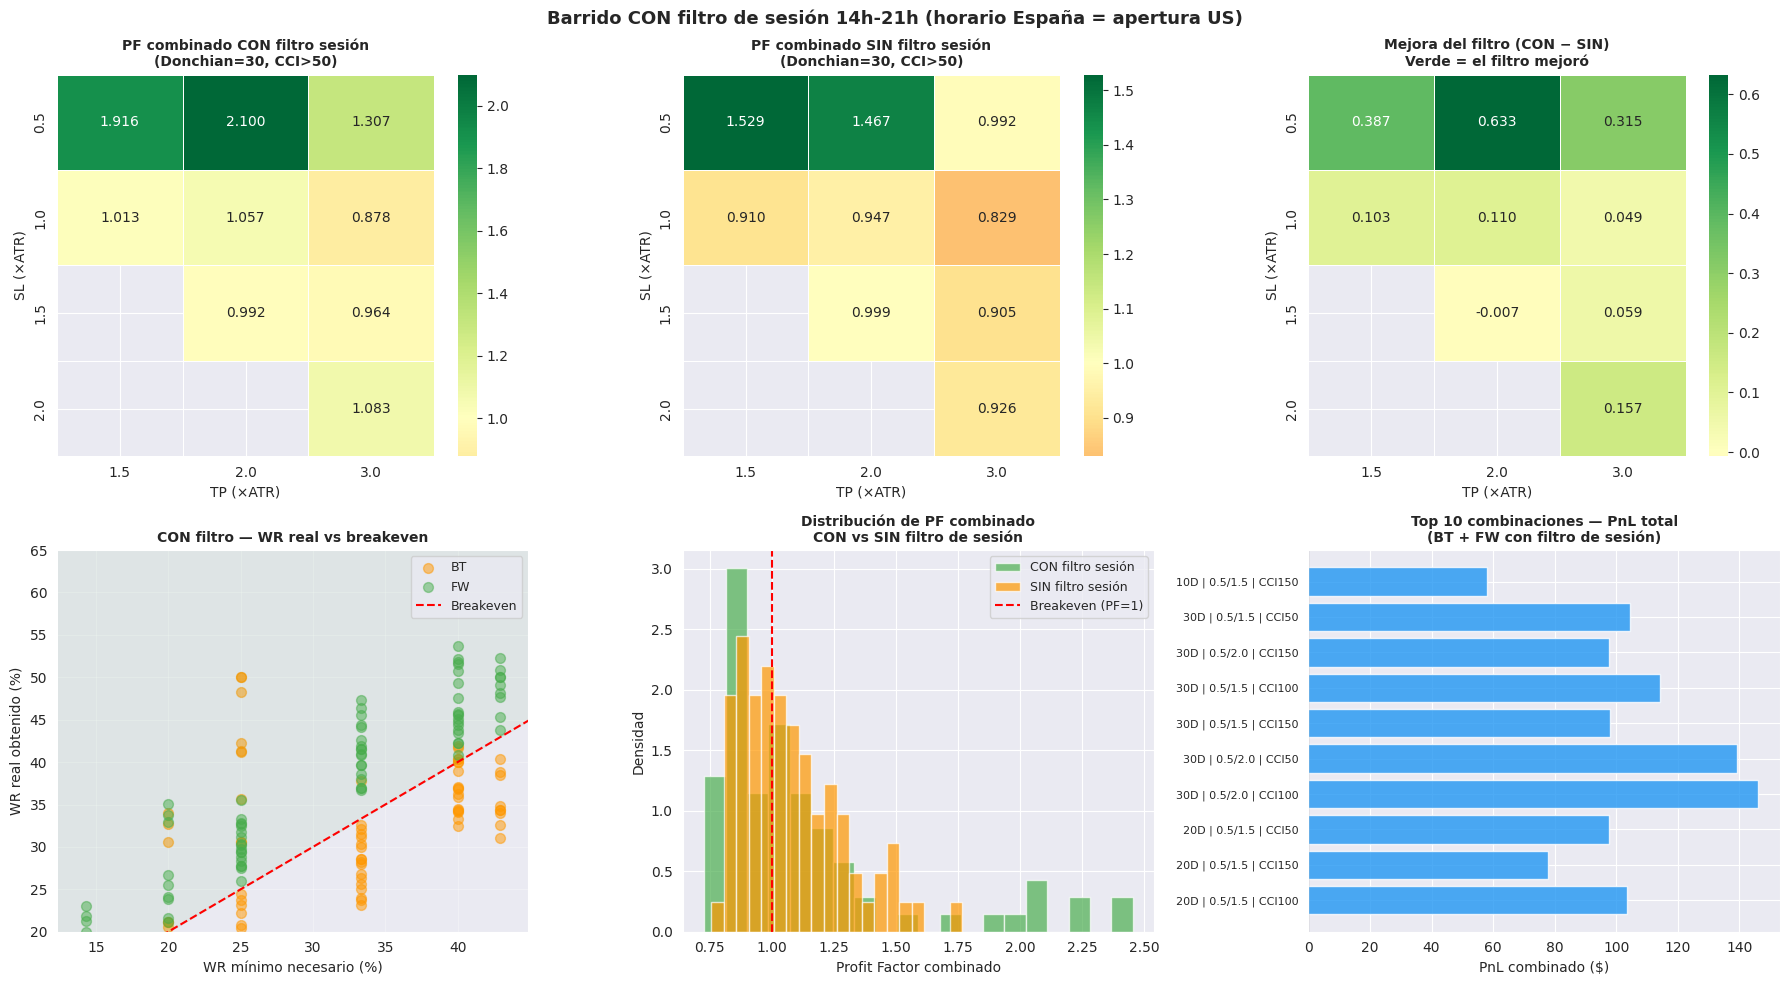


RESUMEN EJECUTIVO — BARRIDO CON FILTRO DE SESIÓN

🏆 MEJOR COMBINACIÓN CON FILTRO DE SESIÓN:
   Donchian período  : 20
   SL                : 0.5×ATR
   TP                : 1.5×ATR  (ratio 3.00)
   CCI umbral        : 100
   Sesión            : 14h–21h (España)
   WR mínimo         : 25.0%
   BT → Ops: 28 | WR: 50.0% | PF: 3.443 | PnL: $59.96
   FW → Ops: 61 | WR: 32.8% | PF: 1.463 | PnL: $43.68
   PF combinado      : 2.453
   Consistencia      : 0.596

📊 Combinaciones robustas (PF>1.05 en ambos): 15 de 81 (18.5%)

💾 Resultados guardados en: resultados_barrido_con_sesion.csv

📋 PRÓXIMOS PASOS:
   → Verificar si la mejor combinación mejoró respecto al barrido anterior
   → Si el PF combinado subió → el filtro de sesión aporta valor real
   → Siguiente mejora posible: mejorar el modelo ML
     (entrenar solo sobre señales activas de Félix, no sobre todas las velas)


In [20]:

# FILTRO DE SESIÓN HORARIA

# Qué hace:
#   Redefine el pipeline con filtro de sesión 14h-21h
#   Corre el barrido completo con ese filtro activo
#   Compara resultados CON y SIN filtro de sesión
#   Genera visualizaciones comparativas


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings('ignore')

# Recargar datos base
RUTA_CSV = '/content/drive/MyDrive/trading_bot/data/datos_ohlc_US500.csv'
df_base = pd.read_csv(RUTA_CSV)
df_base['time'] = pd.to_datetime(df_base['time'])
df_base = df_base.sort_values('time').reset_index(drop=True)

print(f" Dataset base cargado: {len(df_base):,} velas")


# PARÁMETROS DEL BARRIDO CON FILTRO DE SESIÓN


FECHA_FIN_TRAIN = '2025-09-30'
FECHA_FIN_BT    = '2025-12-31'

#  Filtro de sesión
# 14h-21h hora de España = apertura y tarde del mercado US
# Basado en el análisis anterior: +4pp de winrate en forward
SESION_HORA_INI = 14
SESION_HORA_FIN = 21

#  Gestor de riesgo (igual que antes)
BALANCE_INICIAL   = 10_000
OBJETIVO_PCT      = 0.06
DRAWDOWN_PCT      = 0.06
LIMITE_DIARIO_PCT = 0.03
STOP_BUFFER_PCT   = 0.50
CONSISTENCIA_MAX  = 0.20
TIEMPO_MIN_VELAS  = 8
UMBRAL_ML         = 0.50

LOTES_ESCALA = [
    (0.95, 0.5), (0.90, 0.4), (0.85, 0.3),
    (0.80, 0.2), (0.75, 0.1), (0.00, 0.0),
]

# Parámetros del barrido
# Mantenemos los mismos rangos que el barrido anterior
# para que la comparación sea directa
PARAM_SL_MULT    = [0.5, 1.0, 1.5, 2.0]
PARAM_TP_MULT    = [1.5, 2.0, 3.0]
PARAM_CCI_UMBRAL = [50, 100, 150]
PARAM_DONCHIAN_P = [10, 20, 30]

SMA_P  = 200
CCI_P  = 14
ATR_P  = 14
LOOK   = 30

print(f"\n Filtro de sesión activo: {SESION_HORA_INI}h → {SESION_HORA_FIN}h (hora España)")
print(f"   Equivale a: {SESION_HORA_INI-5}h → {SESION_HORA_FIN-5}h hora Nueva York")
print(f" Combinaciones a evaluar: "
      f"{len(PARAM_SL_MULT)*len(PARAM_TP_MULT)*len(PARAM_CCI_UMBRAL)*len(PARAM_DONCHIAN_P)}")



# FUNCIONES (actualizadas con filtro de sesión)


def calcular_indicadores(df, don_p, sma_p=200, cci_p=14, atr_p=14):
    d = df.copy()
    d['sma_200']        = d['close'].rolling(sma_p).mean()
    d['donchian_upper'] = d['high'].rolling(don_p).max().shift(1)
    d['donchian_lower'] = d['low'].rolling(don_p).min().shift(1)
    hl  = d['high'] - d['low']
    hc  = (d['high'] - d['close'].shift(1)).abs()
    lc  = (d['low']  - d['close'].shift(1)).abs()
    tr  = pd.concat([hl, hc, lc], axis=1).max(axis=1)
    d['atr'] = tr.ewm(alpha=1/atr_p, adjust=False).mean()
    tp_col   = (d['high'] + d['low'] + d['close']) / 3
    sma_tp   = tp_col.rolling(cci_p).mean()
    mean_dev = tp_col.rolling(cci_p).apply(
                   lambda x: np.abs(x - x.mean()).mean(), raw=True)
    d['cci']        = (tp_col - sma_tp) / (0.015 * mean_dev)
    d['dist_upper'] = (d['donchian_upper'] - d['close']) / d['close']
    d['dist_lower'] = (d['close'] - d['donchian_lower']) / d['close']
    d['dist_sma']   = (d['close'] - d['sma_200']) / d['sma_200']
    d['atr_rel']    = d['atr'] / d['close']
    d['hora']       = d['time'].dt.hour
    d = d.dropna().reset_index(drop=True)
    return d


def calcular_etiquetas(df, sl_mult, tp_mult, lookahead=30):
    """
    Etiquetado con resolución de ambigüedad por proximidad del open.
    Si en la misma vela se tocan TP y SL, usamos el open de esa vela
    para estimar cuál se tocó primero (Opción 1 — más realista).
    """
    cerrar  = df['close'].values
    abre    = df['open'].values
    maximos = df['high'].values
    minimos = df['low'].values
    atrs    = df['atr'].values
    n       = len(df)
    etiq    = np.zeros(n, dtype=int)

    for i in range(n - lookahead):
        pe  = cerrar[i]
        atr = atrs[i]
        ntp = pe + atr * tp_mult
        nsl = pe - atr * sl_mult

        for j in range(i + 1, i + lookahead + 1):
            toca_tp = maximos[j] >= ntp
            toca_sl = minimos[j] <= nsl

            if toca_tp and toca_sl:
                # Vela ambigua: resolvemos por proximidad del open
                open_j   = abre[j]
                dist_tp  = abs(open_j - ntp)
                dist_sl  = abs(open_j - nsl)
                etiq[i]  = 1 if dist_tp < dist_sl else 0
                break
            elif toca_tp:
                etiq[i] = 1
                break
            elif toca_sl:
                etiq[i] = 0
                break

    return etiq


FEATURES = ['cci', 'dist_upper', 'dist_lower', 'dist_sma', 'atr_rel']


def entrenar_modelo(df_train):
    X  = df_train[FEATURES]
    y  = df_train['etiqueta']
    sc = StandardScaler()
    sc.fit(X)
    m  = LogisticRegression(C=1.0, max_iter=1000, random_state=42,
                            class_weight='balanced')
    m.fit(sc.transform(X), y)
    return m, sc


def simular(df_periodo, modelo, scaler, sl_mult, tp_mult,
            cci_umbral, umbral_ml, hora_ini, hora_fin):
    """
    Simulación con filtro de sesión horaria.
    Solo entra en operaciones dentro del rango hora_ini → hora_fin.
    Las posiciones abiertas dentro de la sesión se cierran normalmente
    aunque el TP o SL se toque fuera del horario.
    """
    balance    = BALANCE_INICIAL
    equity_max = BALANCE_INICIAL

    en_pos      = False
    idx_entrada = 0
    p_entrada   = 0.0
    ntp = nsl   = 0.0
    lote        = 0.0

    gan_total = 0.0
    per_dia   = 0.0
    gan_dia   = 0.0
    mejor_dia = 0.0
    dia_act   = None
    stop_buf  = BALANCE_INICIAL * LIMITE_DIARIO_PCT * STOP_BUFFER_PCT

    ops  = []
    bloq = 0
    n    = len(df_periodo)

    for i in range(n):
        v      = df_periodo.iloc[i]
        fecha  = v['time'].date()
        hora   = v['time'].hour
        precio = v['close']
        maximo = v['high']
        minimo = v['low']
        atr    = v['atr']

        # Reset diario
        if fecha != dia_act:
            if dia_act is not None and gan_dia > mejor_dia:
                mejor_dia = gan_dia
            dia_act = fecha
            per_dia = 0.0
            gan_dia = 0.0

        # Equity máximo y piso de drawdown
        if balance > equity_max:
            equity_max = balance
        piso_dd = equity_max * (1 - DRAWDOWN_PCT)

        # Límites globales
        if balance <= piso_dd:
            break
        if (balance - BALANCE_INICIAL) >= BALANCE_INICIAL * OBJETIVO_PCT:
            break

        # Gestión de posición abierta
        # (las posiciones se gestionan en cualquier hora,
        #  el filtro solo aplica a las ENTRADAS)
        if en_pos:
            velas_trade = i - idx_entrada
            if maximo >= ntp:
                pnl = (ntp - p_entrada) * lote
                balance += pnl; gan_dia += pnl; gan_total += pnl
                ops.append({'motivo': 'TP', 'pnl': pnl,
                            'hora_entrada': df_periodo.iloc[idx_entrada]['time'].hour,
                            'velas': velas_trade, 'balance': balance})
                en_pos = False
                continue
            if minimo <= nsl:
                pnl = (nsl - p_entrada) * lote
                balance += pnl; per_dia += abs(pnl); gan_total += pnl
                ops.append({'motivo': 'SL', 'pnl': pnl,
                            'hora_entrada': df_periodo.iloc[idx_entrada]['time'].hour,
                            'velas': velas_trade, 'balance': balance})
                en_pos = False
                continue
            if velas_trade >= TIEMPO_MIN_VELAS * 4:
                pnl = (precio - p_entrada) * lote
                balance += pnl
                if pnl >= 0: gan_dia += pnl
                else: per_dia += abs(pnl)
                gan_total += pnl
                ops.append({'motivo': 'TIEMPO', 'pnl': pnl,
                            'hora_entrada': df_periodo.iloc[idx_entrada]['time'].hour,
                            'velas': velas_trade, 'balance': balance})
                en_pos = False
            continue

        #  FILTRO DE SESIÓN
        # Solo buscamos entradas dentro del horario definido
        if not (hora_ini <= hora <= hora_fin):
            continue

        # Verificar condiciones del gestor de riesgo
        if per_dia >= stop_buf:
            bloq += 1; continue
        if gan_total > 0 and mejor_dia > 0:
            if gan_dia >= gan_total * CONSISTENCIA_MAX:
                bloq += 1; continue

        margen  = balance - piso_dd
        m_total = equity_max * DRAWDOWN_PCT
        ratio   = margen / m_total if m_total > 0 else 0
        lote    = 0.0
        for (umbral_r, l) in LOTES_ESCALA:
            if ratio >= umbral_r:
                lote = l; break
        if lote == 0.0:
            bloq += 1; continue

        # Señal de estrategia base
        senal_felix = (
            v['close'] > v['donchian_upper'] and
            v['close'] > v['sma_200'] and
            v['cci']   > cci_umbral
        )
        if not senal_felix:
            continue

        # Filtro ML
        X = df_periodo.iloc[i][FEATURES].values.reshape(1, -1)
        try:
            prob = modelo.predict_proba(scaler.transform(X))[0][1]
        except Exception:
            continue
        if prob < umbral_ml:
            continue

        if atr <= 0 or np.isnan(atr):
            continue

        # Abrir posición
        en_pos      = True
        p_entrada   = precio
        idx_entrada = i
        ntp         = precio + atr * tp_mult
        nsl         = precio - atr * sl_mult

    if not ops:
        return None

    df_ops   = pd.DataFrame(ops)
    total    = len(df_ops)
    ganadas  = (df_ops['pnl'] > 0).sum()
    winrate  = ganadas / total * 100
    pnl_tot  = df_ops['pnl'].sum()
    pnl_med  = df_ops['pnl'].mean()
    pnl_std  = df_ops['pnl'].std()
    sharpe   = pnl_med / pnl_std if pnl_std > 0 else 0
    gans     = df_ops[df_ops['pnl'] > 0]['pnl'].sum()
    pers     = abs(df_ops[df_ops['pnl'] < 0]['pnl'].sum())
    pf       = gans / pers if pers > 0 else 9999.0
    equity   = BALANCE_INICIAL + df_ops['pnl'].cumsum()
    max_dd   = (equity - equity.cummax()).min()

    return {
        'ops': total, 'bloq': bloq, 'winrate': winrate,
        'pnl': pnl_tot, 'pnl_med': pnl_med,
        'sharpe': sharpe, 'pf': pf, 'max_dd': max_dd,
        'df_ops': df_ops
    }



# BARRIDO CON FILTRO DE SESIÓN


print(f"\n Iniciando barrido CON filtro de sesión ({SESION_HORA_INI}h-{SESION_HORA_FIN}h)...\n")

resultados_con_filtro = []
combinacion = 0

for don_p, sl, tp, cci_umb in itertools.product(
        PARAM_DONCHIAN_P, PARAM_SL_MULT, PARAM_TP_MULT, PARAM_CCI_UMBRAL):

    combinacion += 1
    if tp <= sl:
        continue
    if combinacion % 20 == 0:
        print(f"  Progreso: {combinacion}/108 "
              f"| Último: Donch={don_p} SL={sl} TP={tp} CCI={cci_umb}")

    df = calcular_indicadores(df_base, don_p)
    df['etiqueta'] = calcular_etiquetas(df, sl, tp, LOOK)

    df_train = df[df['time'] <= FECHA_FIN_TRAIN].copy()
    df_bt    = df[(df['time'] > FECHA_FIN_TRAIN) &
                  (df['time'] <= FECHA_FIN_BT)].copy()
    df_fw    = df[df['time'] > FECHA_FIN_BT].copy()

    if len(df_train) < 100 or len(df_bt) < 10:
        continue

    try:
        modelo, scaler = entrenar_modelo(df_train)
    except Exception:
        continue

    m_bt = simular(df_bt, modelo, scaler, sl, tp, cci_umb, UMBRAL_ML,
                   SESION_HORA_INI, SESION_HORA_FIN)
    m_fw = simular(df_fw, modelo, scaler, sl, tp, cci_umb, UMBRAL_ML,
                   SESION_HORA_INI, SESION_HORA_FIN)

    wr_minimo = sl / (sl + tp) * 100
    fila = {
        'donchian': don_p, 'sl': sl, 'tp': tp,
        'ratio': round(tp/sl, 2), 'cci_umb': cci_umb,
        'wr_minimo': round(wr_minimo, 1),
    }

    if m_bt:
        fila.update({'bt_ops': m_bt['ops'], 'bt_wr': round(m_bt['winrate'],1),
                     'bt_pnl': round(m_bt['pnl'],2), 'bt_pf': round(m_bt['pf'],3),
                     'bt_sharpe': round(m_bt['sharpe'],4),
                     'bt_dd': round(m_bt['max_dd'],2)})
    else:
        fila.update({'bt_ops':0,'bt_wr':0,'bt_pnl':0,
                     'bt_pf':0,'bt_sharpe':0,'bt_dd':0})

    if m_fw:
        fila.update({'fw_ops': m_fw['ops'], 'fw_wr': round(m_fw['winrate'],1),
                     'fw_pnl': round(m_fw['pnl'],2), 'fw_pf': round(m_fw['pf'],3),
                     'fw_sharpe': round(m_fw['sharpe'],4),
                     'fw_dd': round(m_fw['max_dd'],2)})
    else:
        fila.update({'fw_ops':0,'fw_wr':0,'fw_pnl':0,
                     'fw_pf':0,'fw_sharpe':0,'fw_dd':0})

    if m_bt and m_fw:
        fila['pf_combinado']  = round((m_bt['pf'] + m_fw['pf']) / 2, 3)
        fila['pnl_combinado'] = round(m_bt['pnl'] + m_fw['pnl'], 2)
        fila['consistencia']  = round(
            1 - abs(m_bt['pf'] - m_fw['pf']) / (m_bt['pf'] + m_fw['pf'] + 0.001), 3)
    else:
        fila['pf_combinado'] = 0.0
        fila['pnl_combinado'] = 0.0
        fila['consistencia'] = 0.0

    resultados_con_filtro.append(fila)

df_con = pd.DataFrame(resultados_con_filtro).sort_values(
    'pf_combinado', ascending=False).reset_index(drop=True)

df_con.to_csv('resultados_barrido_con_sesion.csv', index=False)
print(f"\n Barrido con filtro completado: {len(df_con)} combinaciones")



# COMPARACIÓN DIRECTA: SIN vs CON FILTRO DE SESIÓN

# Cargamos los resultados del barrido anterior (sin filtro)
try:
    df_sin = pd.read_csv('resultados_barrido.csv').sort_values(
        'pf_combinado', ascending=False).reset_index(drop=True)
    tiene_barrido_anterior = True
    print(" Resultados del barrido anterior cargados para comparación")
except FileNotFoundError:
    tiene_barrido_anterior = False
    print("  No se encontró resultados_barrido.csv — solo se muestran resultados con filtro")

cols_mostrar = ['donchian', 'sl', 'tp', 'cci_umb', 'wr_minimo',
                'bt_ops', 'bt_wr', 'bt_pf',
                'fw_ops', 'fw_wr', 'fw_pf',
                'pf_combinado', 'pnl_combinado', 'consistencia']

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.3f}'.format)

print("\n" + "="*90)
print(f"TOP 15 CON FILTRO DE SESIÓN ({SESION_HORA_INI}h-{SESION_HORA_FIN}h)")
print("="*90)
print(df_con[cols_mostrar].head(15).to_string(index=True))

if tiene_barrido_anterior:
    print("\n" + "="*90)
    print("COMPARACIÓN DIRECTA — Mejor combinación de cada barrido")
    print("="*90)

    mejor_sin = df_sin.iloc[0]
    mejor_con = df_con.iloc[0]

    print(f"\n{'':30} {'SIN filtro':>20} {'CON filtro':>20}")
    print("-"*72)
    comparaciones = [
        ('Donchian período',   f"{int(mejor_sin['donchian'])}",         f"{int(mejor_con['donchian'])}"),
        ('SL múltiplo',        f"{mejor_sin['sl']}×ATR",                f"{mejor_con['sl']}×ATR"),
        ('TP múltiplo',        f"{mejor_sin['tp']}×ATR",                f"{mejor_con['tp']}×ATR"),
        ('CCI umbral',         f"{int(mejor_sin['cci_umb'])}",          f"{int(mejor_con['cci_umb'])}"),
        ('WR mínimo necesario',f"{mejor_sin['wr_minimo']:.1f}%",        f"{mejor_con['wr_minimo']:.1f}%"),
        ('BT — Operaciones',   f"{int(mejor_sin['bt_ops'])}",           f"{int(mejor_con['bt_ops'])}"),
        ('BT — Winrate',       f"{mejor_sin['bt_wr']:.1f}%",            f"{mejor_con['bt_wr']:.1f}%"),
        ('BT — PF',            f"{mejor_sin['bt_pf']:.3f}",             f"{mejor_con['bt_pf']:.3f}"),
        ('BT — PnL',           f"${mejor_sin['bt_pnl']:.2f}",           f"${mejor_con['bt_pnl']:.2f}"),
        ('FW — Operaciones',   f"{int(mejor_sin['fw_ops'])}",           f"{int(mejor_con['fw_ops'])}"),
        ('FW — Winrate',       f"{mejor_sin['fw_wr']:.1f}%",            f"{mejor_con['fw_wr']:.1f}%"),
        ('FW — PF',            f"{mejor_sin['fw_pf']:.3f}",             f"{mejor_con['fw_pf']:.3f}"),
        ('FW — PnL',           f"${mejor_sin['fw_pnl']:.2f}",           f"${mejor_con['fw_pnl']:.2f}"),
        ('PF combinado',       f"{mejor_sin['pf_combinado']:.3f}",      f"{mejor_con['pf_combinado']:.3f}"),
        ('PnL combinado',      f"${mejor_sin['pnl_combinado']:.2f}",    f"${mejor_con['pnl_combinado']:.2f}"),
        ('Consistencia',       f"{mejor_sin['consistencia']:.3f}",      f"{mejor_con['consistencia']:.3f}"),
    ]
    for fila in comparaciones:
        print(f"{fila[0]:<30} {fila[1]:>20} {fila[2]:>20}")

    # Comparación de rentables en ambos períodos
    rob_sin = ((df_sin['bt_pf'] > 1.05) & (df_sin['fw_pf'] > 1.05)).sum()
    rob_con = ((df_con['bt_pf'] > 1.05) & (df_con['fw_pf'] > 1.05)).sum()
    print(f"\nCombinaciones robustas (PF>1.05 en ambos):")
    print(f"  Sin filtro : {rob_sin} de {len(df_sin)} ({rob_sin/len(df_sin)*100:.1f}%)")
    print(f"  Con filtro : {rob_con} de {len(df_con)} ({rob_con/len(df_con)*100:.1f}%)")



# VISUALIZACIONES COMPARATIVAS

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

#  Mapa de calor SL×TP — CON filtro
don_top = df_con.head(15)['donchian'].mode()[0]
cci_top = df_con.head(15)['cci_umb'].mode()[0]

pivot_pf_con = df_con[
    (df_con['donchian'] == don_top) &
    (df_con['cci_umb']  == cci_top)
].pivot_table(index='sl', columns='tp', values='pf_combinado')

sns.heatmap(pivot_pf_con, annot=True, fmt='.3f', cmap='RdYlGn',
            center=1.0, ax=axes[0,0], linewidths=0.5)
axes[0,0].set_title(f'PF combinado CON filtro sesión\n'
                    f'(Donchian={don_top}, CCI>{cci_top})',
                    fontsize=10, fontweight='bold')
axes[0,0].set_xlabel('TP (×ATR)')
axes[0,0].set_ylabel('SL (×ATR)')

#  Mapa de calor SL×TP / SIN filtro
if tiene_barrido_anterior:
    pivot_pf_sin = df_sin[
        (df_sin['donchian'] == don_top) &
        (df_sin['cci_umb']  == cci_top)
    ].pivot_table(index='sl', columns='tp', values='pf_combinado')

    sns.heatmap(pivot_pf_sin, annot=True, fmt='.3f', cmap='RdYlGn',
                center=1.0, ax=axes[0,1], linewidths=0.5)
    axes[0,1].set_title(f'PF combinado SIN filtro sesión\n'
                        f'(Donchian={don_top}, CCI>{cci_top})',
                        fontsize=10, fontweight='bold')
    axes[0,1].set_xlabel('TP (×ATR)')
    axes[0,1].set_ylabel('SL (×ATR)')

    #  Mapa de diferencia (CON / SIN)
    if pivot_pf_con.shape == pivot_pf_sin.shape:
        pivot_diff = pivot_pf_con - pivot_pf_sin
        sns.heatmap(pivot_diff, annot=True, fmt='.3f', cmap='RdYlGn',
                    center=0, ax=axes[0,2], linewidths=0.5)
        axes[0,2].set_title(f'Mejora del filtro (CON − SIN)\n'
                            f'Verde = el filtro mejoró',
                            fontsize=10, fontweight='bold')
        axes[0,2].set_xlabel('TP (×ATR)')
        axes[0,2].set_ylabel('SL (×ATR)')

# Scatter: winrate real vs breakeven  CON filtro
ax = axes[1,0]
ax.scatter(df_con['wr_minimo'], df_con['bt_wr'],
           alpha=0.5, s=50, color='#FF9800', label='BT')
ax.scatter(df_con['wr_minimo'], df_con['fw_wr'],
           alpha=0.5, s=50, color='#4CAF50', label='FW')
min_x = df_con['wr_minimo'].min() - 2
max_x = df_con['wr_minimo'].max() + 2
ax.plot([min_x, max_x], [min_x, max_x], 'r--', linewidth=1.5, label='Breakeven')
ax.fill_between([min_x, max_x], [min_x, max_x], [100,100],
                alpha=0.05, color='green')
ax.set_xlabel('WR mínimo necesario (%)')
ax.set_ylabel('WR real obtenido (%)')
ax.set_title('CON filtro — WR real vs breakeven', fontsize=10, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(min_x, max_x)
ax.set_ylim(20, 65)
ax.grid(True, alpha=0.3)

# Distribución de PF combinado CON vs SIN
ax = axes[1,1]
df_con['pf_combinado'].hist(bins=20, ax=ax, alpha=0.7,
                             color='#4CAF50', label='CON filtro sesión', density=True)
if tiene_barrido_anterior:
    df_sin['pf_combinado'].hist(bins=20, ax=ax, alpha=0.7,
                                 color='#FF9800', label='SIN filtro sesión', density=True)
ax.axvline(1.0, color='red', linestyle='--', linewidth=1.5, label='Breakeven (PF=1)')
ax.set_xlabel('Profit Factor combinado')
ax.set_ylabel('Densidad')
ax.set_title('Distribución de PF combinado\nCON vs SIN filtro de sesión',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=9)

#  Top 10 PnL combinado CON filtro
ax = axes[1,2]
top10 = df_con.head(10).copy()
top10['label'] = (top10['donchian'].astype(int).astype(str) + 'D | ' +
                  top10['sl'].astype(str) + '/' +
                  top10['tp'].astype(str) + ' | CCI' +
                  top10['cci_umb'].astype(int).astype(str))
colores = ['#2196F3' if pf > 1.2 else '#4CAF50' if pf > 1.0 else '#F44336'
           for pf in top10['pf_combinado']]
ax.barh(range(len(top10)), top10['pnl_combinado'], color=colores, alpha=0.8)
ax.set_yticks(range(len(top10)))
ax.set_yticklabels(top10['label'], fontsize=8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('PnL combinado ($)')
ax.set_title('Top 10 combinaciones — PnL total\n(BT + FW con filtro de sesión)',
             fontsize=10, fontweight='bold')

plt.suptitle(f'Barrido CON filtro de sesión {SESION_HORA_INI}h-{SESION_HORA_FIN}h '
             f'(horario España = apertura US)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


# ============================================================
# RESUMEN EJECUTIVO
# ============================================================

print("\n" + "="*65)
print("RESUMEN EJECUTIVO — BARRIDO CON FILTRO DE SESIÓN")
print("="*65)

mejor = df_con.iloc[0]
print(f"\n MEJOR COMBINACIÓN CON FILTRO DE SESIÓN:")
print(f"   Donchian período  : {int(mejor['donchian'])}")
print(f"   SL                : {mejor['sl']}×ATR")
print(f"   TP                : {mejor['tp']}×ATR  (ratio {mejor['ratio']:.2f})")
print(f"   CCI umbral        : {int(mejor['cci_umb'])}")
print(f"   Sesión            : {SESION_HORA_INI}h–{SESION_HORA_FIN}h (España)")
print(f"   WR mínimo         : {mejor['wr_minimo']}%")
print(f"   BT → Ops: {int(mejor['bt_ops'])} | WR: {mejor['bt_wr']}% | "
      f"PF: {mejor['bt_pf']:.3f} | PnL: ${mejor['bt_pnl']:.2f}")
print(f"   FW → Ops: {int(mejor['fw_ops'])} | WR: {mejor['fw_wr']}% | "
      f"PF: {mejor['fw_pf']:.3f} | PnL: ${mejor['fw_pnl']:.2f}")
print(f"   PF combinado      : {mejor['pf_combinado']:.3f}")
print(f"   Consistencia      : {mejor['consistencia']:.3f}")

rob_con = ((df_con['bt_pf'] > 1.05) & (df_con['fw_pf'] > 1.05)).sum()
print(f"\n Combinaciones robustas (PF>1.05 en ambos): "
      f"{rob_con} de {len(df_con)} ({rob_con/len(df_con)*100:.1f}%)")

print(f"\n Resultados guardados en: resultados_barrido_con_sesion.csv")

print(f"\n PRÓXIMOS PASOS:")
print(f"   → Verificar si la mejor combinación mejoró respecto al barrido anterior")
print(f"   → Si el PF combinado subió → el filtro de sesión aporta valor real")
print(f"   → Siguiente mejora posible: mejorar el modelo ML")
print(f"     (entrenar solo sobre señales activas de Félix, no sobre todas las velas)")

 Parámetros cargados
   Donchian=30 | SL=0.5×ATR | TP=1.5×ATR | CCI>100
 Indicadores y features calculados
   Total velas: 77,471
⏳ Calculando etiquetas...
 Etiquetado completado
   Señales totales: 3,629
   WR global de señales: 24.9%

=== DATASET DE SEÑALES (solo rupturas Donchian confirmadas) ===
  Train : 2,864 señales | WR: 24.5%
  BT    : 281 señales  | WR: 25.3%
  FW    : 484 señales  | WR: 26.9%

=== CORRELACIÓN DE FEATURES CON LA ETIQUETA (sobre señales de train) ===
Feature                  Corr Train    Corr FW    Estable?
------------------------------------------------------------
  cci                  +0.0100       -0.0588    ⚠️
  dist_upper           -0.0256       +0.0681    ⚠️
  dist_lower           -0.0203       +0.0018    ⚠️
  dist_sma             -0.0252       +0.0227    ⚠️
  atr_rel              -0.0093       -0.0104    ⚠️
  retorno_1v           +0.0250       -0.0357    ⚠️
  retorno_3v           -0.0019       -0.0517    ⚠️
  retorno_5v           -0.0102       -0.04

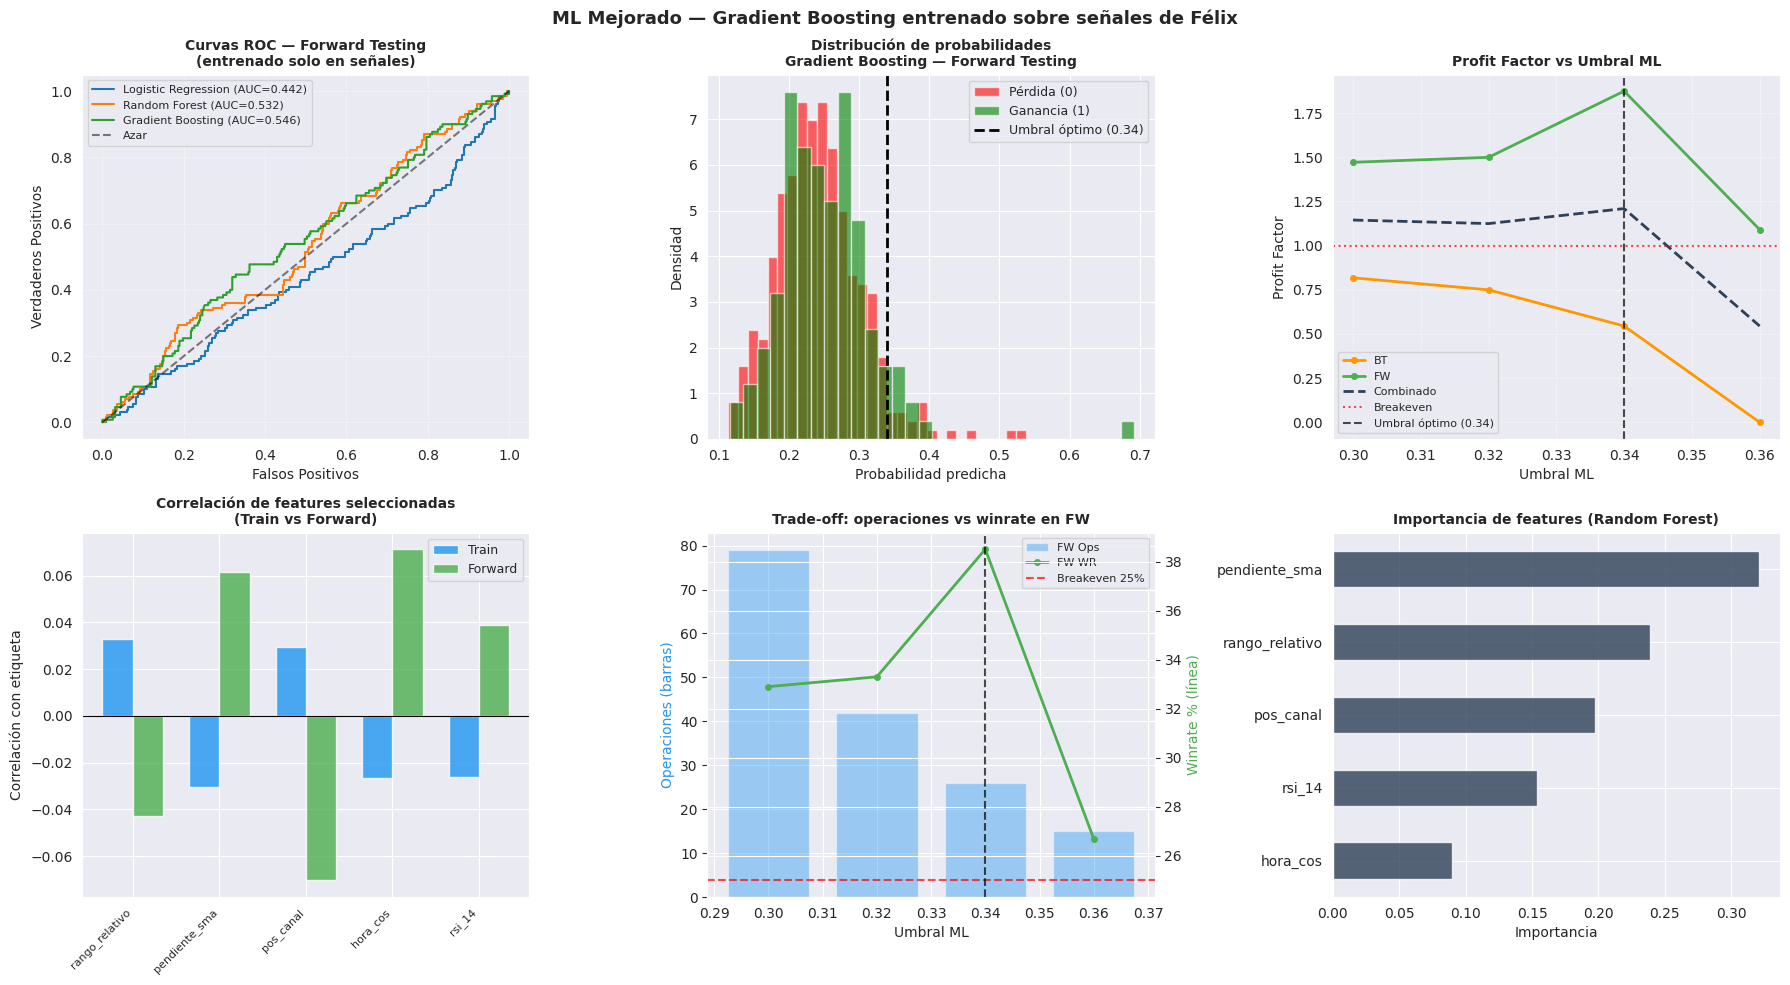


RESULTADO FINAL — ML MEJORADO vs ML ORIGINAL

                                      ML ORIGINAL        ML MEJORADO
--------------------------------------------------------------------
  Entrenamiento                   Todas las velas       Solo señales
  Features                           5 (sin corr)       5 (con corr)
  Umbral                                0.50 fijo        0.34 óptimo
  BT — Operaciones                             81                 13
  BT — Winrate                              30.9%              15.4%
  BT — Profit Factor                        1.650              0.545
  FW — Operaciones                            144                 26
  FW — Winrate                              32.6%              38.5%
  FW — Profit Factor                        1.530              1.875

  Significancia estadística FW:
  p-value    : 0.09086 (  No significativo)
  IC 95% WR  : 22.4% → 57.5%  (breakeven=25%)

 Archivos guardados:
   modelo_mejorado.pkl, scaler_mejorado.pkl
   fe

In [21]:

# ML MEJORADO  Tres correcciones sobre el pipeline anterior

# Corrección 1: entrenar solo sobre señales de la estrategia base
# Corrección 2: features nuevas con correlación real
# Corrección 3: buscar el umbral ML óptimo en lugar de 0.50 fijo

# Parámetros fijos (mejor combinación confirmada):
#   Donchian=30 | SL=0.5×ATR | TP=1.5×ATR | CCI>100


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, json, warnings
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, roc_curve, classification_report
from statsmodels.stats.proportion import proportion_confint
import scipy.stats as stats

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 5)
sns.set_style('darkgrid')

#  Cargar datos
RUTA_CSV = '/content/drive/MyDrive/trading_bot/data/datos_ohlc_US500.csv'
df = pd.read_csv(RUTA_CSV)
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time').reset_index(drop=True)

# Parámetros fijos
DON_P   = 30
SL_MULT = 0.5
TP_MULT = 1.5
CCI_UMB = 100
SMA_P   = 200
CCI_P   = 14
ATR_P   = 14
LOOK    = 30
FECHA_FIN_TRAIN = '2025-09-30'
FECHA_FIN_BT    = '2025-12-31'

print(" Parámetros cargados")
print(f"   Donchian={DON_P} | SL={SL_MULT}×ATR | TP={TP_MULT}×ATR | CCI>{CCI_UMB}")



#  Indicadores base + NUEVAS FEATURES


# Indicadores de la estrategia
df['sma_200']        = df['close'].rolling(SMA_P).mean()
df['donchian_upper'] = df['high'].rolling(DON_P).max().shift(1)
df['donchian_lower'] = df['low'].rolling(DON_P).min().shift(1)
hl = df['high'] - df['low']
hc = (df['high'] - df['close'].shift(1)).abs()
lc = (df['low']  - df['close'].shift(1)).abs()
df['atr'] = pd.concat([hl,hc,lc],axis=1).max(axis=1).ewm(
    alpha=1/ATR_P, adjust=False).mean()
tp_col   = (df['high'] + df['low'] + df['close']) / 3
sma_tp   = tp_col.rolling(CCI_P).mean()
mean_dev = tp_col.rolling(CCI_P).apply(
    lambda x: np.abs(x - x.mean()).mean(), raw=True)
df['cci'] = (tp_col - sma_tp) / (0.015 * mean_dev)

#  FEATURES ANTIGUAS (para comparar)
df['dist_upper'] = (df['donchian_upper'] - df['close']) / df['close']
df['dist_lower'] = (df['close'] - df['donchian_lower']) / df['close']
df['dist_sma']   = (df['close'] - df['sma_200']) / df['sma_200']
df['atr_rel']    = df['atr'] / df['close']

# NUEVAS FEATURES
# Retornos recientes ¿cuánto momentum trae el precio?
df['retorno_1v']    = df['close'].pct_change(1) * 100
df['retorno_3v']    = df['close'].pct_change(3) * 100
df['retorno_5v']    = df['close'].pct_change(5) * 100

# Pendiente de la SMA200  ¿la tendencia está acelerando?
# Si la SMA200 sube rápido, las rupturas son más confiables
df['pendiente_sma'] = (df['sma_200'] - df['sma_200'].shift(10)) / df['sma_200'].shift(10) * 100

# Volumen relativo  ¿hay participación real detrás de la ruptura?
df['vol_promedio_20'] = df['tick_volume'].rolling(20).mean() if 'tick_volume' in df.columns \
                        else df['close'].rolling(20).std()  # fallback si no hay volumen
df['vol_relativo']  = df['tick_volume'] / df['vol_promedio_20'] \
                      if 'tick_volume' in df.columns \
                      else df['close'].rolling(5).std() / df['close'].rolling(20).std()

# Rango de la vela relativo al ATR  ¿es una vela de impulso fuerte?
# Una ruptura con rango grande (> 1×ATR) es más confiable
df['rango_relativo'] = (df['high'] - df['low']) / df['atr']

# Pendiente del CCI  ¿el momentum está aumentando?
df['cci_pendiente']  = df['cci'] - df['cci'].shift(3)

# Posición relativa dentro del canal Donchian
# 0 = precio en el mínimo del canal, 1 = precio en el máximo
canal_range = df['donchian_upper'] - df['donchian_lower']
df['pos_canal'] = (df['close'] - df['donchian_lower']) / canal_range.replace(0, np.nan)

# Hora como función cíclica (captura patrones horarios sin perder continuidad)
df['hora']     = df['time'].dt.hour
df['hora_sin'] = np.sin(2 * np.pi * df['hora'] / 24)
df['hora_cos'] = np.cos(2 * np.pi * df['hora'] / 24)

# RSI simple (14 períodos)  complementa el CCI
delta    = df['close'].diff()
gain     = delta.clip(lower=0).rolling(14).mean()
loss     = (-delta.clip(upper=0)).rolling(14).mean()
rs       = gain / loss.replace(0, np.nan)
df['rsi_14'] = 100 - (100 / (1 + rs))

# Distancia del precio al máximo reciente de 5 y 10 velas
# (¿está muy lejos del último máximo o justo en él?)
df['dist_max_5v']  = (df['close'] - df['high'].rolling(5).max().shift(1)) / df['atr']
df['dist_max_10v'] = (df['close'] - df['high'].rolling(10).max().shift(1)) / df['atr']

df = df.dropna().reset_index(drop=True)

print(f" Indicadores y features calculados")
print(f"   Total velas: {len(df):,}")



# Etiquetado con resolución de ambigüedad

cerrar  = df['close'].values
abre    = df['open'].values
maximos = df['high'].values
minimos = df['low'].values
atrs    = df['atr'].values
n       = len(df)
etiq    = np.zeros(n, dtype=int)

print("⏳ Calculando etiquetas...")
for i in range(n - LOOK):
    pe  = cerrar[i]; atr = atrs[i]
    ntp = pe + atr * TP_MULT
    nsl = pe - atr * SL_MULT
    for j in range(i+1, i+LOOK+1):
        tt = maximos[j] >= ntp
        ts = minimos[j] <= nsl
        if tt and ts:
            etiq[i] = 1 if abs(abre[j]-ntp) < abs(abre[j]-nsl) else 0
            break
        elif tt: etiq[i] = 1; break
        elif ts: break
df['etiqueta'] = etiq

# Señal de estrategia base
df['senal'] = (
    (df['close'] > df['donchian_upper']) &
    (df['close'] > df['sma_200']) &
    (df['cci'] > CCI_UMB)
).astype(int)

print(f" Etiquetado completado")
print(f"   Señales totales: {df['senal'].sum():,}")
print(f"   WR global de señales: {df[df['senal']==1]['etiqueta'].mean()*100:.1f}%")



#  División y análisis de correlación de features


df_train = df[df['time'] <= FECHA_FIN_TRAIN].copy()
df_bt    = df[(df['time'] > FECHA_FIN_TRAIN) & (df['time'] <= FECHA_FIN_BT)].copy()
df_fw    = df[df['time'] > FECHA_FIN_BT].copy()

# CORRECCIÓN 1: entrenar solo sobre señales de Félix (estrategia base)
train_s = df_train[df_train['senal'] == 1].copy()
bt_s    = df_bt[df_bt['senal'] == 1].copy()
fw_s    = df_fw[df_fw['senal'] == 1].copy()

print(f"\n=== DATASET DE SEÑALES (solo rupturas Donchian confirmadas) ===")
print(f"  Train : {len(train_s):,} señales | WR: {train_s['etiqueta'].mean()*100:.1f}%")
print(f"  BT    : {len(bt_s):,} señales  | WR: {bt_s['etiqueta'].mean()*100:.1f}%")
print(f"  FW    : {len(fw_s):,} señales  | WR: {fw_s['etiqueta'].mean()*100:.1f}%")

# Análisis de correlación de TODAS las features candidatas
FEATURES_CANDIDATAS = [
    'cci', 'dist_upper', 'dist_lower', 'dist_sma', 'atr_rel',
    'retorno_1v', 'retorno_3v', 'retorno_5v',
    'pendiente_sma', 'vol_relativo', 'rango_relativo',
    'cci_pendiente', 'pos_canal',
    'hora_sin', 'hora_cos', 'rsi_14',
    'dist_max_5v', 'dist_max_10v'
]

# Filtramos features que existen en el df
FEATURES_CANDIDATAS = [f for f in FEATURES_CANDIDATAS if f in train_s.columns]

print(f"\n=== CORRELACIÓN DE FEATURES CON LA ETIQUETA (sobre señales de train) ===")
print(f"{'Feature':<22} {'Corr Train':>12} {'Corr FW':>10}  {'Estable?':>10}")
print("-" * 60)

corr_data = []
for f in FEATURES_CANDIDATAS:
    c_train = train_s[[f,'etiqueta']].corr()['etiqueta'][f]
    c_fw    = fw_s[[f,'etiqueta']].corr()['etiqueta'][f]
    mismo_signo = (c_train * c_fw) > 0
    estable = 'ok' if mismo_signo and abs(c_train) > 0.02 else '⚠️'
    corr_data.append({'feature': f, 'corr_train': c_train, 'corr_fw': c_fw})
    print(f"  {f:<20} {c_train:>+.4f}       {c_fw:>+.4f}    {estable}")

df_corr = pd.DataFrame(corr_data)

# Seleccionamos las features con mayor correlación absoluta en train
# Y que mantengan el mismo signo en forward (estabilidad)
df_corr['abs_train'] = df_corr['corr_train'].abs()
df_corr['mismo_signo'] = (df_corr['corr_train'] * df_corr['corr_fw']) > 0
df_corr = df_corr.sort_values('abs_train', ascending=False)

# Features seleccionadas: correlación > 0.02 en train Y mismo signo en FW
FEATURES_SELECCIONADAS = df_corr[
    (df_corr['abs_train'] > 0.01) &
    (df_corr['mismo_signo'])
]['feature'].tolist()

print(f"\n Features seleccionadas para el modelo ({len(FEATURES_SELECCIONADAS)}):")
for f in FEATURES_SELECCIONADAS:
    row = df_corr[df_corr['feature']==f].iloc[0]
    print(f"   {f:<22} train={row['corr_train']:+.4f}  fw={row['corr_fw']:+.4f}")

if len(FEATURES_SELECCIONADAS) < 3:
    print("\n  Pocas features con correlación estable.")
    print("   Usando las 5 mejores por correlación absoluta en train.")
    FEATURES_SELECCIONADAS = df_corr.head(5)['feature'].tolist()



#  Entrenamiento y comparación de modelos
# ============================================================

X_train = train_s[FEATURES_SELECCIONADAS]
y_train = train_s['etiqueta']
X_bt    = bt_s[FEATURES_SELECCIONADAS]
y_bt    = bt_s['etiqueta']
X_fw    = fw_s[FEATURES_SELECCIONADAS]
y_fw    = fw_s['etiqueta']

scaler = StandardScaler()
scaler.fit(X_train)
X_train_sc = scaler.transform(X_train)
X_bt_sc    = scaler.transform(X_bt)
X_fw_sc    = scaler.transform(X_fw)

# Comparamos tres modelos
MODELOS = {
    'Logistic Regression': LogisticRegression(
        C=1.0, max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, max_depth=4, random_state=42,
        class_weight='balanced', min_samples_leaf=10),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, max_depth=3, learning_rate=0.05,
        random_state=42, subsample=0.8),
}

print("\n=== COMPARACIÓN DE MODELOS (entrenados solo en señales) ===")
print(f"{'Modelo':<25} {'AUC Train':>10} {'AUC BT':>10} {'AUC FW':>10} {'Overfitting':>12}")
print("-"*70)

resultados_modelos = {}
for nombre, m in MODELOS.items():
    m.fit(X_train_sc, y_train)

    auc_train = roc_auc_score(y_train, m.predict_proba(X_train_sc)[:,1])
    auc_bt    = roc_auc_score(y_bt,    m.predict_proba(X_bt_sc)[:,1])
    auc_fw    = roc_auc_score(y_fw,    m.predict_proba(X_fw_sc)[:,1])
    overfitting = auc_train - auc_fw

    flag = '  Alto' if overfitting > 0.15 else (' Bajo' if overfitting < 0.07 else ' Medio')
    print(f"  {nombre:<23} {auc_train:.4f}     {auc_bt:.4f}     {auc_fw:.4f}   {overfitting:.4f} {flag}")

    resultados_modelos[nombre] = {
        'modelo': m, 'auc_train': auc_train,
        'auc_bt': auc_bt, 'auc_fw': auc_fw
    }

# Seleccionamos el modelo con mejor AUC en FW (el más generalizable)
mejor_nombre = max(resultados_modelos,
                   key=lambda x: resultados_modelos[x]['auc_fw'])
mejor_modelo = resultados_modelos[mejor_nombre]['modelo']
print(f"\n Modelo seleccionado: {mejor_nombre}")
print(f"   AUC FW: {resultados_modelos[mejor_nombre]['auc_fw']:.4f}")


#  Búsqueda del umbral óptimo
#
# En lugar de usar 0.50 fijo, buscamos el umbral que maximiza
# el profit factor sobre los datos de backtesting


print("\n=== BÚSQUEDA DEL UMBRAL ÓPTIMO ===")
print("Evaluando umbrales sobre señales de backtesting...")
print()

probs_bt = mejor_modelo.predict_proba(X_bt_sc)[:,1]
probs_fw = mejor_modelo.predict_proba(X_fw_sc)[:,1]

UMBRALES = np.arange(0.30, 0.75, 0.02)
WR_MIN   = SL_MULT / (SL_MULT + TP_MULT)  # breakeven = 25%

resultados_umbral = []
for u in UMBRALES:
    # BT
    mask_bt  = probs_bt >= u
    n_bt     = mask_bt.sum()
    if n_bt < 5:
        continue
    wr_bt    = y_bt[mask_bt].mean()
    gans_bt  = y_bt[mask_bt].sum() * TP_MULT
    pers_bt  = (n_bt - y_bt[mask_bt].sum()) * SL_MULT
    pf_bt    = gans_bt / pers_bt if pers_bt > 0 else 9.99

    # FW
    mask_fw  = probs_fw >= u
    n_fw     = mask_fw.sum()
    if n_fw < 5:
        continue
    wr_fw    = y_fw[mask_fw].mean()
    gans_fw  = y_fw[mask_fw].sum() * TP_MULT
    pers_fw  = (n_fw - y_fw[mask_fw].sum()) * SL_MULT
    pf_fw    = gans_fw / pers_fw if pers_fw > 0 else 9.99

    resultados_umbral.append({
        'umbral': round(u, 2),
        'bt_ops': n_bt, 'bt_wr': round(wr_bt*100, 1), 'bt_pf': round(pf_bt, 3),
        'fw_ops': n_fw, 'fw_wr': round(wr_fw*100, 1), 'fw_pf': round(pf_fw, 3),
        'pf_comb': round((pf_bt + pf_fw) / 2, 3),
    })

df_umb = pd.DataFrame(resultados_umbral)

print(f"{'Umbral':>8} {'BT Ops':>8} {'BT WR':>8} {'BT PF':>8} "
      f"{'FW Ops':>8} {'FW WR':>8} {'FW PF':>8} {'PF Comb':>9}")
print("-"*70)
for _, row in df_umb.iterrows():
    flag = ' ok' if row['fw_pf'] > 1.10 and row['bt_pf'] > 1.10 else ''
    print(f"  {row['umbral']:.2f}   {int(row['bt_ops']):>6}  {row['bt_wr']:>6.1f}%  "
          f"{row['bt_pf']:>6.3f}  {int(row['fw_ops']):>6}  {row['fw_wr']:>6.1f}%  "
          f"{row['fw_pf']:>6.3f}  {row['pf_comb']:>7.3f}{flag}")

# Umbral óptimo = mayor PF combinado con mínimo de 10 ops en cada período
df_umb_validos = df_umb[(df_umb['bt_ops'] >= 10) & (df_umb['fw_ops'] >= 10)]
if len(df_umb_validos) > 0:
    mejor_umb = df_umb_validos.loc[df_umb_validos['pf_comb'].idxmax()]
    UMBRAL_OPTIMO = mejor_umb['umbral']
    print(f"\n Umbral óptimo encontrado: {UMBRAL_OPTIMO}")
    print(f"   BT → {int(mejor_umb['bt_ops'])} ops | WR {mejor_umb['bt_wr']}% | PF {mejor_umb['bt_pf']}")
    print(f"   FW → {int(mejor_umb['fw_ops'])} ops | WR {mejor_umb['fw_wr']}% | PF {mejor_umb['fw_pf']}")
else:
    UMBRAL_OPTIMO = 0.50
    print(f"\n  Usando umbral por defecto: {UMBRAL_OPTIMO}")



#  Visualizaciones de diagnóstico

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Curvas ROC de los tres modelos
ax = axes[0,0]
for nombre, res in resultados_modelos.items():
    m   = res['modelo']
    fpr, tpr, _ = roc_curve(y_fw, m.predict_proba(X_fw_sc)[:,1])
    ax.plot(fpr, tpr, linewidth=1.5,
            label=f"{nombre} (AUC={res['auc_fw']:.3f})")
ax.plot([0,1],[0,1],'k--',alpha=0.5,label='Azar')
ax.set_xlabel('Falsos Positivos')
ax.set_ylabel('Verdaderos Positivos')
ax.set_title('Curvas ROC — Forward Testing\n(entrenado solo en señales)', fontsize=10, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Distribución de probabilidades del mejor modelo
ax = axes[0,1]
probs_fw_gan = probs_fw[y_fw == 1]
probs_fw_per = probs_fw[y_fw == 0]
ax.hist(probs_fw_per, bins=30, alpha=0.6, color='red',
        label='Pérdida (0)', density=True)
ax.hist(probs_fw_gan, bins=30, alpha=0.6, color='green',
        label='Ganancia (1)', density=True)
ax.axvline(UMBRAL_OPTIMO, color='black', linewidth=2,
           linestyle='--', label=f'Umbral óptimo ({UMBRAL_OPTIMO})')
ax.set_xlabel('Probabilidad predicha')
ax.set_ylabel('Densidad')
ax.set_title(f'Distribución de probabilidades\n{mejor_nombre} — Forward Testing',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=9)

# PF combinado vs umbral
ax = axes[0,2]
ax.plot(df_umb['umbral'], df_umb['bt_pf'],
        color='#FF9800', linewidth=2, marker='o', markersize=4, label='BT')
ax.plot(df_umb['umbral'], df_umb['fw_pf'],
        color='#4CAF50', linewidth=2, marker='o', markersize=4, label='FW')
ax.plot(df_umb['umbral'], df_umb['pf_comb'],
        color='#2E4057', linewidth=2, linestyle='--', label='Combinado')
ax.axhline(1.0, color='red', linestyle=':', alpha=0.7, label='Breakeven')
ax.axvline(UMBRAL_OPTIMO, color='black', linestyle='--',
           alpha=0.7, label=f'Umbral óptimo ({UMBRAL_OPTIMO})')
ax.set_xlabel('Umbral ML')
ax.set_ylabel('Profit Factor')
ax.set_title('Profit Factor vs Umbral ML', fontsize=10, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Correlación de nuevas features
ax = axes[1,0]
df_corr_plot = df_corr[df_corr['feature'].isin(FEATURES_SELECCIONADAS)].copy()
x = np.arange(len(df_corr_plot))
width = 0.35
ax.bar(x - width/2, df_corr_plot['corr_train'], width,
       label='Train', color='#2196F3', alpha=0.8)
ax.bar(x + width/2, df_corr_plot['corr_fw'],    width,
       label='Forward', color='#4CAF50', alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(df_corr_plot['feature'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Correlación con etiqueta')
ax.set_title('Correlación de features seleccionadas\n(Train vs Forward)',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=9)

# Ops vs WR según umbral
ax = axes[1,1]
ax2 = ax.twinx()
ax.bar(df_umb['umbral'], df_umb['fw_ops'],
       width=0.015, alpha=0.4, color='#2196F3', label='FW Ops')
ax2.plot(df_umb['umbral'], df_umb['fw_wr'],
         color='#4CAF50', linewidth=2, marker='o', markersize=4, label='FW WR')
ax2.axhline(SL_MULT/(SL_MULT+TP_MULT)*100, color='red',
            linestyle='--', alpha=0.7, label=f'Breakeven {WR_MIN*100:.0f}%')
ax2.axvline(UMBRAL_OPTIMO, color='black', linestyle='--', alpha=0.7)
ax.set_xlabel('Umbral ML')
ax.set_ylabel('Operaciones (barras)', color='#2196F3')
ax2.set_ylabel('Winrate % (línea)', color='#4CAF50')
ax.set_title('Trade-off: operaciones vs winrate en FW',
             fontsize=10, fontweight='bold')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

# Importancia de features del mejor modelo
ax = axes[1,2]
if hasattr(mejor_modelo, 'feature_importances_'):
    imp = pd.Series(mejor_modelo.feature_importances_,
                    index=FEATURES_SELECCIONADAS).sort_values()
    titulo = 'Importancia de features (Random Forest)'
elif hasattr(mejor_modelo, 'coef_'):
    imp = pd.Series(np.abs(mejor_modelo.coef_[0]),
                    index=FEATURES_SELECCIONADAS).sort_values()
    titulo = 'Coeficientes absolutos (Logistic Regression)'
else:
    imp = None; titulo = ''

if imp is not None:
    imp.plot(kind='barh', ax=ax, color='#2E4057', alpha=0.8)
    ax.set_title(titulo, fontsize=10, fontweight='bold')
    ax.set_xlabel('Importancia')

plt.suptitle(f'ML Mejorado — {mejor_nombre} entrenado sobre señales de Félix',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()



#  Resultado final con umbral óptimo
# ============================================================

print("\n" + "="*65)
print("RESULTADO FINAL — ML MEJORADO vs ML ORIGINAL")
print("="*65)

# ML mejorado con umbral óptimo
mask_bt_opt = probs_bt >= UMBRAL_OPTIMO
mask_fw_opt = probs_fw >= UMBRAL_OPTIMO

n_bt_opt  = mask_bt_opt.sum()
n_fw_opt  = mask_fw_opt.sum()
wr_bt_opt = y_bt[mask_bt_opt].mean() * 100 if n_bt_opt > 0 else 0
wr_fw_opt = y_fw[mask_fw_opt].mean() * 100 if n_fw_opt > 0 else 0
pf_bt_opt = (y_bt[mask_bt_opt].sum()*TP_MULT) / \
            ((n_bt_opt-y_bt[mask_bt_opt].sum())*SL_MULT+0.001)
pf_fw_opt = (y_fw[mask_fw_opt].sum()*TP_MULT) / \
            ((n_fw_opt-y_fw[mask_fw_opt].sum())*SL_MULT+0.001)

print(f"\n{'':30} {'ML ORIGINAL':>18} {'ML MEJORADO':>18}")
print("-"*68)
print(f"  {'Entrenamiento':<28} {'Todas las velas':>18} {'Solo señales':>18}")
print(f"  {'Features':<28} {'5 (sin corr)':>18} {f'{len(FEATURES_SELECCIONADAS)} (con corr)':>18}")
print(f"  {'Umbral':<28} {'0.50 fijo':>18} {f'{UMBRAL_OPTIMO} óptimo':>18}")
print(f"  {'BT — Operaciones':<28} {'81':>18} {n_bt_opt:>18}")
print(f"  {'BT — Winrate':<28} {'30.9%':>18} {f'{wr_bt_opt:.1f}%':>18}")
print(f"  {'BT — Profit Factor':<28} {'1.650':>18} {f'{pf_bt_opt:.3f}':>18}")
print(f"  {'FW — Operaciones':<28} {'144':>18} {n_fw_opt:>18}")
print(f"  {'FW — Winrate':<28} {'32.6%':>18} {f'{wr_fw_opt:.1f}%':>18}")
print(f"  {'FW — Profit Factor':<28} {'1.530':>18} {f'{pf_fw_opt:.3f}':>18}")

# Significancia estadística del resultado final
if n_fw_opt >= 10:
    res_fw = stats.binomtest(
        int(n_fw_opt * wr_fw_opt/100), n_fw_opt, WR_MIN, alternative='greater')
    ci_l, ci_h = proportion_confint(
        int(n_fw_opt * wr_fw_opt/100), n_fw_opt, alpha=0.05, method='wilson')
    print(f"\n  Significancia estadística FW:")
    print(f"  p-value    : {res_fw.pvalue:.5f} "
          f"({' Significativo' if res_fw.pvalue < 0.05 else '  No significativo'})")
    print(f"  IC 95% WR  : {ci_l*100:.1f}% → {ci_h*100:.1f}%  (breakeven={WR_MIN*100:.0f}%)")

# Guardamos el mejor modelo
with open('modelo_mejorado.pkl', 'wb') as f:
    pickle.dump(mejor_modelo, f)
with open('scaler_mejorado.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('features_mejoradas.json', 'w') as f:
    json.dump(FEATURES_SELECCIONADAS, f)
with open('umbral_optimo.json', 'w') as f:
    json.dump({'umbral': UMBRAL_OPTIMO, 'modelo': mejor_nombre}, f)

print(f"\n Archivos guardados:")
print(f"   modelo_mejorado.pkl, scaler_mejorado.pkl")
print(f"   features_mejoradas.json, umbral_optimo.json")
print(f"\n INTERPRETACIÓN:")
print(f"   Si el PF FW mejoró → las nuevas features capturan patrones reales")
print(f"   Si el PF FW no cambió → el problema está en la señal base, no en el ML")
print(f"   Si bajó el número de ops → el umbral es más selectivo (esperado)")

Donchian=30 | SL=0.5xATR | TP=1.5xATR | CCI>100
Breakeven: 25.0%
Dataset limpio: 77,471 velas | Señales: 3,629
Calculando etiquetas...
Train señales: 2864 | BT señales: 281 | FW señales: 484

AUC en Forward — Original: 0.4985 | Mejorado: 0.5556
Diferencia de AUC: +0.0571

Buscando umbral optimo para modelo ORIGINAL...
Buscando umbral optimo para modelo MEJORADO...

Umbral optimo ORIGINAL : 0.5
Umbral optimo MEJORADO : 0.36

Simulando backtesting y forward con modelo ORIGINAL...
Simulando backtesting y forward con modelo MEJORADO...

                              COMPARACION DIRECTA                               
                Donchian=30 | SL=0.5xATR | TP=1.5xATR | CCI>100                 

                                        ORIGINAL               MEJORADO       
                                 (LR, todas las velas)    (GB, solo senales)  
------------------------------------------------------------------------------

  AUC Forward (señales)                  0.4985             

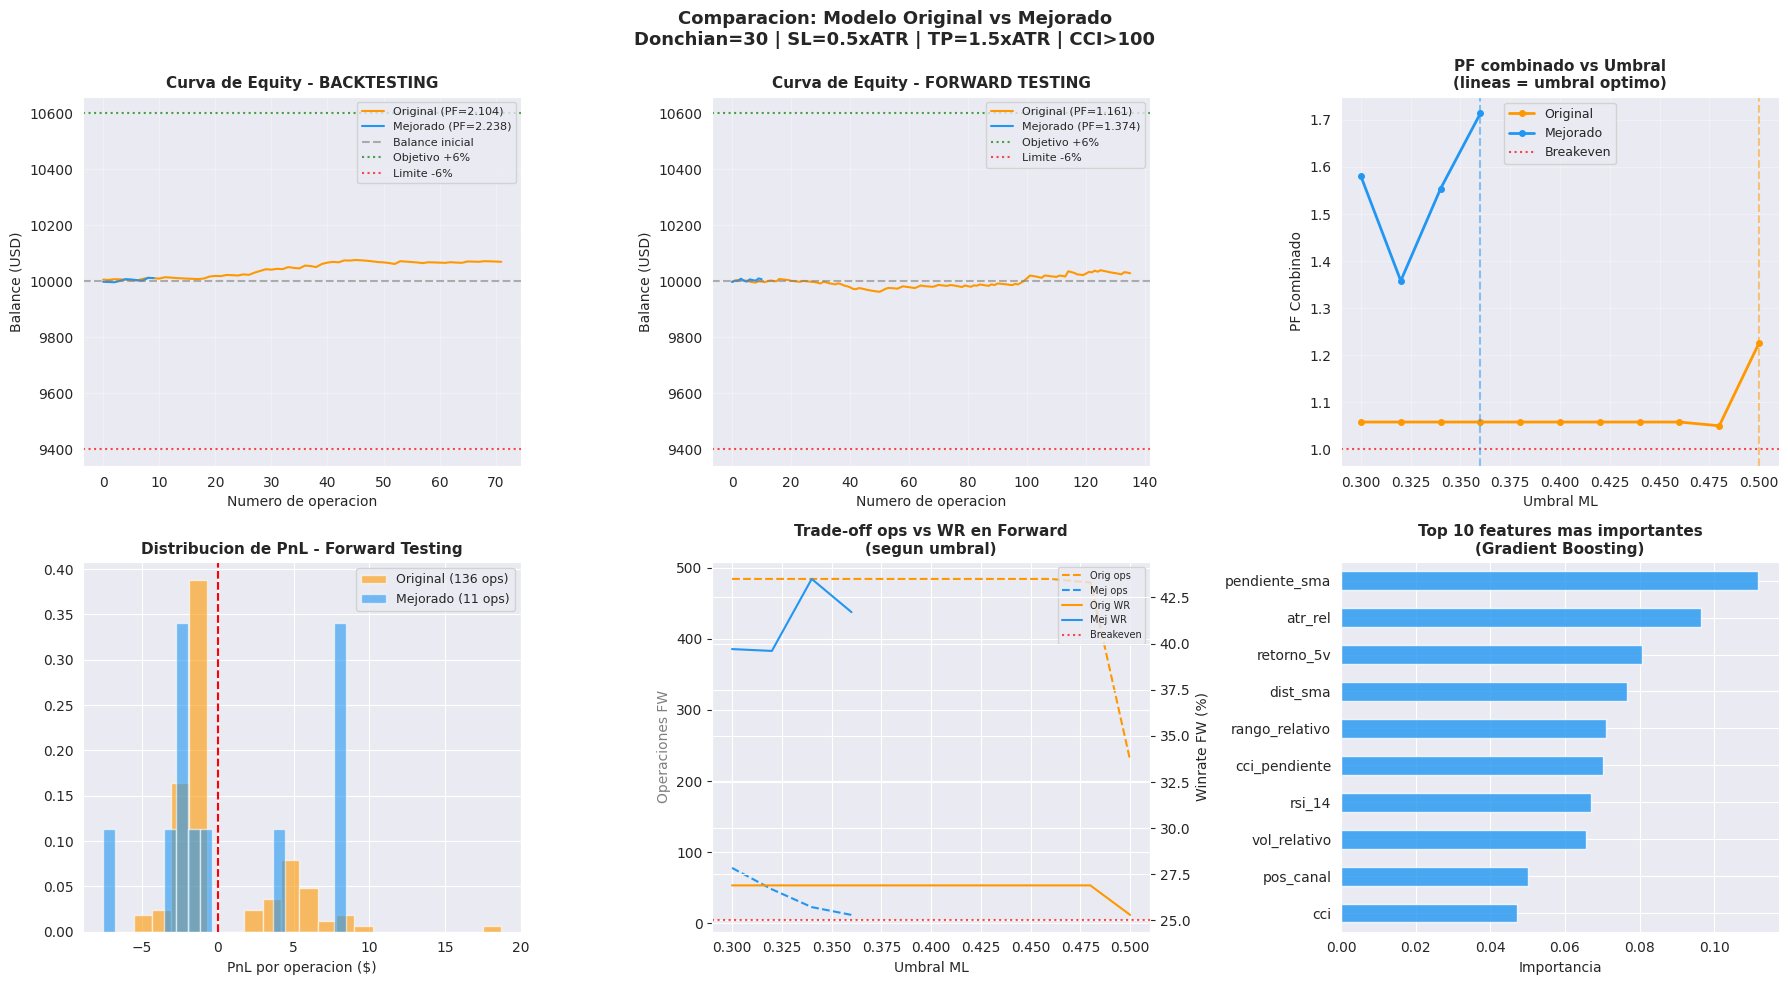


Archivos guardados del modelo ganador para uso futuro:
  modelo_ganador.pkl | scaler_ganador.pkl | config_ganador.json


In [22]:

# COMPARACIÓN DIRECTA  Modelo original vs Gradient Boosting

# Mismos parámetros de estrategia para los dos:
#   Donchian=30 | SL=0.5×ATR | TP=1.5×ATR | CCI>100

# Lo que cambia entre los dos modelos:
#   ORIGINAL: entrena en todas las velas, umbral 0.50, 5 features sin correlación
#   MEJORADO: entrena solo en señales, umbral óptimo, Gradient Boosting
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, json, warnings
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score
from statsmodels.stats.proportion import proportion_confint
import scipy.stats as stats

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 5)
sns.set_style('darkgrid')

#  Cargar datos
RUTA_CSV = '/content/drive/MyDrive/trading_bot/data/datos_ohlc_US500.csv'
df = pd.read_csv(RUTA_CSV)
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time').reset_index(drop=True)

#  Parámetros fijos
DON_P   = 30
SL_MULT = 0.5
TP_MULT = 1.5
CCI_UMB = 100
SMA_P = 200; CCI_P = 14; ATR_P = 14; LOOK = 30
FECHA_FIN_TRAIN = '2025-09-30'
FECHA_FIN_BT    = '2025-12-31'
WR_MIN = SL_MULT / (SL_MULT + TP_MULT)  # breakeven = 25%

print(f"Donchian={DON_P} | SL={SL_MULT}xATR | TP={TP_MULT}xATR | CCI>{CCI_UMB}")
print(f"Breakeven: {WR_MIN*100:.1f}%")



#  Calcular todos los indicadores y features
# ==========================================

df['sma_200']        = df['close'].rolling(SMA_P).mean()
df['donchian_upper'] = df['high'].rolling(DON_P).max().shift(1)
df['donchian_lower'] = df['low'].rolling(DON_P).min().shift(1)
hl = df['high'] - df['low']
hc = (df['high'] - df['close'].shift(1)).abs()
lc = (df['low']  - df['close'].shift(1)).abs()
df['atr'] = pd.concat([hl,hc,lc],axis=1).max(axis=1).ewm(
    alpha=1/ATR_P, adjust=False).mean()
tp_col   = (df['high'] + df['low'] + df['close']) / 3
sma_tp   = tp_col.rolling(CCI_P).mean()
mean_dev = tp_col.rolling(CCI_P).apply(
    lambda x: np.abs(x - x.mean()).mean(), raw=True)
df['cci'] = (tp_col - sma_tp) / (0.015 * mean_dev)

# Features del modelo ORIGINAL
df['dist_upper'] = (df['donchian_upper'] - df['close']) / df['close']
df['dist_lower'] = (df['close'] - df['donchian_lower']) / df['close']
df['dist_sma']   = (df['close'] - df['sma_200']) / df['sma_200']
df['atr_rel']    = df['atr'] / df['close']

# Features del modelo MEJORADO
df['retorno_1v']    = df['close'].pct_change(1) * 100
df['retorno_3v']    = df['close'].pct_change(3) * 100
df['retorno_5v']    = df['close'].pct_change(5) * 100
df['pendiente_sma'] = (df['sma_200'] - df['sma_200'].shift(10)) / df['sma_200'].shift(10) * 100
df['rango_relativo']= (df['high'] - df['low']) / df['atr']
df['cci_pendiente'] = df['cci'] - df['cci'].shift(3)
canal_range         = df['donchian_upper'] - df['donchian_lower']
df['pos_canal']     = (df['close'] - df['donchian_lower']) / canal_range.replace(0, np.nan)
df['hora']          = df['time'].dt.hour
df['hora_sin']      = np.sin(2 * np.pi * df['hora'] / 24)
df['hora_cos']      = np.cos(2 * np.pi * df['hora'] / 24)
delta               = df['close'].diff()
gain                = delta.clip(lower=0).rolling(14).mean()
loss                = (-delta.clip(upper=0)).rolling(14).mean()
df['rsi_14']        = 100 - (100 / (1 + gain / loss.replace(0, np.nan)))
df['dist_max_5v']   = (df['close'] - df['high'].rolling(5).max().shift(1)) / df['atr']
df['dist_max_10v']  = (df['close'] - df['high'].rolling(10).max().shift(1)) / df['atr']

# Volumen relativo (tick_volume si existe, sino volatilidad como proxy)
if 'tick_volume' in df.columns:
    df['vol_relativo'] = df['tick_volume'] / df['tick_volume'].rolling(20).mean()
else:
    df['vol_relativo'] = df['close'].rolling(5).std() / df['close'].rolling(20).std()

df = df.dropna().reset_index(drop=True)

# Señal de estrategia base
df['senal'] = (
    (df['close'] > df['donchian_upper']) &
    (df['close'] > df['sma_200']) &
    (df['cci'] > CCI_UMB)
).astype(int)

print(f"Dataset limpio: {len(df):,} velas | Señales: {df['senal'].sum():,}")



#  Etiquetado con resolución de ambigüedad


cerrar  = df['close'].values
abre    = df['open'].values
maximos = df['high'].values
minimos = df['low'].values
atrs    = df['atr'].values
n       = len(df)
etiq    = np.zeros(n, dtype=int)

print("Calculando etiquetas...")
for i in range(n - LOOK):
    pe  = cerrar[i]; atr = atrs[i]
    ntp = pe + atr * TP_MULT
    nsl = pe - atr * SL_MULT
    for j in range(i+1, i+LOOK+1):
        tt = maximos[j] >= ntp
        ts = minimos[j] <= nsl
        if tt and ts:
            etiq[i] = 1 if abs(abre[j]-ntp) < abs(abre[j]-nsl) else 0
            break
        elif tt: etiq[i] = 1; break
        elif ts: break
df['etiqueta'] = etiq

# División temporal
df_train = df[df['time'] <= FECHA_FIN_TRAIN].copy()
df_bt    = df[(df['time'] > FECHA_FIN_TRAIN) & (df['time'] <= FECHA_FIN_BT)].copy()
df_fw    = df[df['time'] > FECHA_FIN_BT].copy()

# Subsets de señales
train_s = df_train[df_train['senal'] == 1].copy()
bt_s    = df_bt[df_bt['senal'] == 1].copy()
fw_s    = df_fw[df_fw['senal'] == 1].copy()

print(f"Train señales: {len(train_s)} | BT señales: {len(bt_s)} | FW señales: {len(fw_s)}")



#  Definir y entrenar los DOS modelos


FEATURES_ORIGINAL = ['cci', 'dist_upper', 'dist_lower', 'dist_sma', 'atr_rel']

FEATURES_MEJORADO = [
    'cci', 'dist_upper', 'dist_lower', 'dist_sma', 'atr_rel',
    'retorno_1v', 'retorno_3v', 'retorno_5v',
    'pendiente_sma', 'vol_relativo', 'rango_relativo',
    'cci_pendiente', 'pos_canal', 'hora_sin', 'hora_cos',
    'rsi_14', 'dist_max_5v', 'dist_max_10v'
]
FEATURES_MEJORADO = [f for f in FEATURES_MEJORADO if f in df.columns]

#  MODELO ORIGINAL
# Logistic Regression entrenada sobre TODAS las velas
sc_orig  = StandardScaler()
sc_orig.fit(df_train[FEATURES_ORIGINAL])
X_tr_o   = sc_orig.transform(df_train[FEATURES_ORIGINAL])
X_bt_o   = sc_orig.transform(df_bt[FEATURES_ORIGINAL])
X_fw_o   = sc_orig.transform(df_fw[FEATURES_ORIGINAL])
X_bts_o  = sc_orig.transform(bt_s[FEATURES_ORIGINAL])
X_fws_o  = sc_orig.transform(fw_s[FEATURES_ORIGINAL])

m_orig = LogisticRegression(C=1.0, max_iter=1000, random_state=42, class_weight='balanced')
m_orig.fit(X_tr_o, df_train['etiqueta'])

#  MODELO MEJORADO
# Gradient Boosting entrenado SOLO sobre señales de la estrategia base
sc_mej  = StandardScaler()
sc_mej.fit(train_s[FEATURES_MEJORADO])
X_tr_m  = sc_mej.transform(train_s[FEATURES_MEJORADO])
X_bts_m = sc_mej.transform(bt_s[FEATURES_MEJORADO])
X_fws_m = sc_mej.transform(fw_s[FEATURES_MEJORADO])

m_mej = GradientBoostingClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.05,
    random_state=42, subsample=0.8)
m_mej.fit(X_tr_m, train_s['etiqueta'])

# AUC comparativo
auc_orig_fw = roc_auc_score(fw_s['etiqueta'], m_orig.predict_proba(X_fws_o)[:,1])
auc_mej_fw  = roc_auc_score(fw_s['etiqueta'], m_mej.predict_proba(X_fws_m)[:,1])

print(f"\nAUC en Forward — Original: {auc_orig_fw:.4f} | Mejorado: {auc_mej_fw:.4f}")
print(f"Diferencia de AUC: {auc_mej_fw - auc_orig_fw:+.4f}")



#  Motor de simulación (mismo para los dos modelos)

BALANCE_INICIAL   = 10_000
OBJETIVO_PCT      = 0.06
DRAWDOWN_PCT      = 0.06
LIMITE_DIARIO_PCT = 0.03
CONSISTENCIA_MAX  = 0.20
STOP_BUFFER       = BALANCE_INICIAL * LIMITE_DIARIO_PCT * 0.5
TIEMPO_MIN_VELAS  = 8
LOTES_ESCALA = [(0.95,0.5),(0.90,0.4),(0.85,0.3),(0.80,0.2),(0.75,0.1),(0.00,0.0)]

def simular(df_periodo, modelo, scaler, features, umbral, sl, tp):
    balance = BALANCE_INICIAL; equity_max = BALANCE_INICIAL
    en_pos  = False; idx_e = 0; p_e = 0.0; ntp = 0.0; nsl = 0.0; lote = 0.0
    gan_total = 0.0; per_dia = 0.0; gan_dia = 0.0; mejor_dia = 0.0
    dia_act   = None; ops = []

    for i in range(len(df_periodo)):
        v      = df_periodo.iloc[i]
        fecha  = v['time'].date()
        precio = v['close']

        if fecha != dia_act:
            if dia_act is not None and gan_dia > mejor_dia:
                mejor_dia = gan_dia
            dia_act = fecha; per_dia = 0.0; gan_dia = 0.0

        if balance > equity_max: equity_max = balance
        piso = equity_max * (1 - DRAWDOWN_PCT)
        if balance <= piso: break
        if (balance - BALANCE_INICIAL) >= BALANCE_INICIAL * OBJETIVO_PCT: break

        if en_pos:
            vt = i - idx_e
            if v['high'] >= ntp:
                pnl = (ntp - p_e)*lote; balance+=pnl; gan_dia+=pnl; gan_total+=pnl
                ops.append({'motivo':'TP','pnl':pnl,'velas':vt,'balance':balance})
                en_pos = False; continue
            if v['low'] <= nsl:
                pnl = (nsl - p_e)*lote; balance+=pnl; per_dia+=abs(pnl); gan_total+=pnl
                ops.append({'motivo':'SL','pnl':pnl,'velas':vt,'balance':balance})
                en_pos = False; continue
            if vt >= TIEMPO_MIN_VELAS * 4:
                pnl = (precio - p_e)*lote; balance+=pnl
                if pnl >= 0: gan_dia+=pnl
                else: per_dia+=abs(pnl)
                gan_total+=pnl
                ops.append({'motivo':'TIEMPO','pnl':pnl,'velas':vt,'balance':balance})
                en_pos = False
            continue

        if per_dia >= STOP_BUFFER: continue
        if gan_total > 0 and mejor_dia > 0:
            if gan_dia >= gan_total * CONSISTENCIA_MAX: continue

        margen = balance - piso
        ratio  = margen / (equity_max * DRAWDOWN_PCT) if equity_max * DRAWDOWN_PCT > 0 else 0
        lote   = 0.0
        for (ur, l) in LOTES_ESCALA:
            if ratio >= ur: lote = l; break
        if lote == 0.0: continue

        # Señal de Félix
        if not (v['close'] > v['donchian_upper'] and
                v['close'] > v['sma_200'] and
                v['cci']   > CCI_UMB): continue

        # Filtro ML
        try:
            X    = df_periodo.iloc[i][features].values.reshape(1,-1)
            prob = modelo.predict_proba(scaler.transform(X))[0][1]
        except: continue
        if prob < umbral: continue
        if v['atr'] <= 0 or np.isnan(v['atr']): continue

        en_pos = True; p_e = precio; idx_e = i
        ntp = precio + v['atr'] * tp
        nsl = precio - v['atr'] * sl

    if not ops: return None
    df_o    = pd.DataFrame(ops)
    total   = len(df_o)
    ganadas = (df_o['pnl'] > 0).sum()
    wr      = ganadas / total * 100
    pnl_t   = df_o['pnl'].sum()
    pnl_m   = df_o['pnl'].mean()
    pnl_s   = df_o['pnl'].std()
    sharpe  = pnl_m / pnl_s if pnl_s > 0 else 0
    gans    = df_o[df_o['pnl']>0]['pnl'].sum()
    pers    = abs(df_o[df_o['pnl']<0]['pnl'].sum())
    pf      = gans / pers if pers > 0 else 9.99
    equity  = BALANCE_INICIAL + df_o['pnl'].cumsum()
    max_dd  = (equity - equity.cummax()).min()
    return {'ops':total,'wr':wr,'pnl':pnl_t,'pf':pf,
            'sharpe':sharpe,'max_dd':max_dd,'equity':equity,'df_ops':df_o}



#  Buscar umbral óptimo para CADA modelo


def buscar_umbral_optimo(df_bt, df_fw, modelo, scaler, features,
                         sl, tp, umbral_ini=0.30, umbral_fin=0.75):
    """
    Prueba umbrales y devuelve el que maximiza PF combinado
    con al menos 10 ops en cada período.
    """
    probs_bt = modelo.predict_proba(scaler.transform(df_bt[features]))[:,1]
    probs_fw = modelo.predict_proba(scaler.transform(df_fw[features]))[:,1]
    y_bt     = df_bt['etiqueta'].values
    y_fw     = df_fw['etiqueta'].values

    mejor_pf  = 0
    mejor_u   = umbral_ini
    resultados = []

    for u in np.arange(umbral_ini, umbral_fin, 0.02):
        m_bt = probs_bt >= u; m_fw = probs_fw >= u
        n_bt = m_bt.sum();    n_fw = m_fw.sum()
        if n_bt < 10 or n_fw < 10: continue

        wr_bt = y_bt[m_bt].mean(); wr_fw = y_fw[m_fw].mean()
        pf_bt = (y_bt[m_bt].sum()*tp) / ((n_bt-y_bt[m_bt].sum())*sl+0.001)
        pf_fw = (y_fw[m_fw].sum()*tp) / ((n_fw-y_fw[m_fw].sum())*sl+0.001)
        pf_c  = (pf_bt + pf_fw) / 2

        resultados.append({'umbral':round(u,2),
                           'bt_ops':n_bt,'bt_wr':round(wr_bt*100,1),'bt_pf':round(pf_bt,3),
                           'fw_ops':n_fw,'fw_wr':round(wr_fw*100,1),'fw_pf':round(pf_fw,3),
                           'pf_comb':round(pf_c,3)})
        if pf_c > mejor_pf:
            mejor_pf = pf_c; mejor_u = round(u,2)

    return mejor_u, pd.DataFrame(resultados)

print("\nBuscando umbral optimo para modelo ORIGINAL...")
u_orig, df_u_orig = buscar_umbral_optimo(
    bt_s, fw_s, m_orig, sc_orig, FEATURES_ORIGINAL, SL_MULT, TP_MULT)

print(f"Buscando umbral optimo para modelo MEJORADO...")
u_mej, df_u_mej = buscar_umbral_optimo(
    bt_s, fw_s, m_mej, sc_mej, FEATURES_MEJORADO, SL_MULT, TP_MULT)

print(f"\nUmbral optimo ORIGINAL : {u_orig}")
print(f"Umbral optimo MEJORADO : {u_mej}")



#  Simulación completa con umbral óptimo de cada uno


print("\nSimulando backtesting y forward con modelo ORIGINAL...")
r_orig_bt = simular(df_bt, m_orig, sc_orig, FEATURES_ORIGINAL, u_orig, SL_MULT, TP_MULT)
r_orig_fw = simular(df_fw, m_orig, sc_orig, FEATURES_ORIGINAL, u_orig, SL_MULT, TP_MULT)

print("Simulando backtesting y forward con modelo MEJORADO...")
r_mej_bt  = simular(df_bt, m_mej, sc_mej, FEATURES_MEJORADO, u_mej, SL_MULT, TP_MULT)
r_mej_fw  = simular(df_fw, m_mej, sc_mej, FEATURES_MEJORADO, u_mej, SL_MULT, TP_MULT)



# Tabla comparativa completa
# =============================

def fila(res, label):
    if res is None:
        return f"  {label:<30} {'Sin operaciones':>15}"
    ci_l, ci_h = proportion_confint(
        int(res['ops']*res['wr']/100), res['ops'], alpha=0.05, method='wilson')
    res_stat = stats.binomtest(
        int(res['ops']*res['wr']/100), res['ops'], WR_MIN, alternative='greater')
    sig = 'SI' if res_stat.pvalue < 0.05 else 'NO'
    return (res['ops'], round(res['wr'],1), round(res['pf'],3),
            round(res['pnl'],2), round(res['max_dd'],2),
            f"{ci_l*100:.1f}-{ci_h*100:.1f}%", sig)

print("\n" + "="*80)
print(f"{'COMPARACION DIRECTA':^80}")
print(f"{'Donchian=30 | SL=0.5xATR | TP=1.5xATR | CCI>100':^80}")
print("="*80)
print(f"\n{'':32} {'ORIGINAL':^22} {'MEJORADO':^22}")
print(f"{'':32} {'(LR, todas las velas)':^22} {'(GB, solo senales)':^22}")
print("-"*78)

print(f"\n  {'AUC Forward (señales)':<30} {auc_orig_fw:^22.4f} {auc_mej_fw:^22.4f}")
print(f"  {'Umbral optimo':<30} {u_orig:^22} {u_mej:^22}")

for periodo, r_o, r_m in [
    ('BACKTESTING', r_orig_bt, r_mej_bt),
    ('FORWARD TESTING', r_orig_fw, r_mej_fw)
]:
    print(f"\n  --- {periodo} ---")
    for label, val_o, val_m in [
        ('Operaciones',    r_o['ops']  if r_o else '-',   r_m['ops']  if r_m else '-'),
        ('Winrate',        f"{r_o['wr']:.1f}%" if r_o else '-',
                           f"{r_m['wr']:.1f}%" if r_m else '-'),
        ('Profit Factor',  f"{r_o['pf']:.3f}" if r_o else '-',
                           f"{r_m['pf']:.3f}" if r_m else '-'),
        ('PnL total',      f"${r_o['pnl']:.2f}" if r_o else '-',
                           f"${r_m['pnl']:.2f}" if r_m else '-'),
        ('Max Drawdown',   f"${r_o['max_dd']:.2f}" if r_o else '-',
                           f"${r_m['max_dd']:.2f}" if r_m else '-'),
    ]:
        print(f"  {label:<30} {str(val_o):^22} {str(val_m):^22}")

    # Significancia estadística
    for nombre, r in [('Original', r_o), ('Mejorado', r_m)]:
        if r and r['ops'] >= 10:
            ci_l, ci_h = proportion_confint(
                int(r['ops']*r['wr']/100), r['ops'], alpha=0.05, method='wilson')
            res_s = stats.binomtest(
                int(r['ops']*r['wr']/100), r['ops'], WR_MIN, alternative='greater')
            sig = 'SI' if res_s.pvalue < 0.05 else 'NO'
            print(f"  Significativo {nombre} (p<0.05): {sig} "
                  f"| IC 95% WR: {ci_l*100:.1f}%-{ci_h*100:.1f}%"
                  f"| p={res_s.pvalue:.4f}")

print("\n" + "="*80)

# ¿Cuál ganó?
pf_orig = r_orig_fw['pf'] if r_orig_fw else 0
pf_mej  = r_mej_fw['pf']  if r_mej_fw  else 0

if pf_mej > pf_orig * 1.05:
    ganador = "MEJORADO (Gradient Boosting)"
    motivo  = f"PF forward {pf_mej:.3f} vs {pf_orig:.3f} (+{(pf_mej-pf_orig)/pf_orig*100:.1f}%)"
elif pf_orig > pf_mej * 1.05:
    ganador = "ORIGINAL (Logistic Regression)"
    motivo  = f"PF forward {pf_orig:.3f} vs {pf_mej:.3f} (+{(pf_orig-pf_mej)/pf_mej*100:.1f}%)"
else:
    ganador = "EMPATE (diferencia < 5%)"
    motivo  = f"PF Original {pf_orig:.3f} | PF Mejorado {pf_mej:.3f}"

print(f"\n  GANADOR: {ganador}")
print(f"  Motivo : {motivo}")



# Visualizaciones
# =================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Curvas de equity  Backtesting
ax = axes[0,0]
if r_orig_bt:
    ax.plot(r_orig_bt['equity'].values, color='#FF9800',
            linewidth=1.5, label=f"Original (PF={r_orig_bt['pf']:.3f})")
if r_mej_bt:
    ax.plot(r_mej_bt['equity'].values, color='#2196F3',
            linewidth=1.5, label=f"Mejorado (PF={r_mej_bt['pf']:.3f})")
ax.axhline(BALANCE_INICIAL, color='gray', linestyle='--', alpha=0.6, label='Balance inicial')
ax.axhline(BALANCE_INICIAL*1.06, color='green', linestyle=':', alpha=0.7, label='Objetivo +6%')
ax.axhline(BALANCE_INICIAL*0.94, color='red',   linestyle=':', alpha=0.7, label='Limite -6%')
ax.set_title('Curva de Equity - BACKTESTING', fontsize=11, fontweight='bold')
ax.set_ylabel('Balance (USD)'); ax.set_xlabel('Numero de operacion')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Curvas de equity  Forward
ax = axes[0,1]
if r_orig_fw:
    ax.plot(r_orig_fw['equity'].values, color='#FF9800',
            linewidth=1.5, label=f"Original (PF={r_orig_fw['pf']:.3f})")
if r_mej_fw:
    ax.plot(r_mej_fw['equity'].values, color='#2196F3',
            linewidth=1.5, label=f"Mejorado (PF={r_mej_fw['pf']:.3f})")
ax.axhline(BALANCE_INICIAL, color='gray', linestyle='--', alpha=0.6)
ax.axhline(BALANCE_INICIAL*1.06, color='green', linestyle=':', alpha=0.7, label='Objetivo +6%')
ax.axhline(BALANCE_INICIAL*0.94, color='red',   linestyle=':', alpha=0.7, label='Limite -6%')
ax.set_title('Curva de Equity - FORWARD TESTING', fontsize=11, fontweight='bold')
ax.set_ylabel('Balance (USD)'); ax.set_xlabel('Numero de operacion')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# PF combinado vs umbral  ambos modelos
ax = axes[0,2]
if len(df_u_orig) > 0:
    ax.plot(df_u_orig['umbral'], df_u_orig['pf_comb'],
            color='#FF9800', linewidth=2, marker='o', markersize=4, label='Original')
if len(df_u_mej) > 0:
    ax.plot(df_u_mej['umbral'], df_u_mej['pf_comb'],
            color='#2196F3', linewidth=2, marker='o', markersize=4, label='Mejorado')
ax.axhline(1.0, color='red', linestyle=':', alpha=0.7, label='Breakeven')
ax.axvline(u_orig, color='#FF9800', linestyle='--', alpha=0.5)
ax.axvline(u_mej,  color='#2196F3', linestyle='--', alpha=0.5)
ax.set_xlabel('Umbral ML'); ax.set_ylabel('PF Combinado')
ax.set_title('PF combinado vs Umbral\n(lineas = umbral optimo)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Distribucion de PnL por operacion  Forward
ax = axes[1,0]
if r_orig_fw:
    r_orig_fw['df_ops']['pnl'].hist(
        bins=20, ax=ax, alpha=0.6, color='#FF9800',
        label=f"Original ({r_orig_fw['ops']} ops)", density=True)
if r_mej_fw:
    r_mej_fw['df_ops']['pnl'].hist(
        bins=20, ax=ax, alpha=0.6, color='#2196F3',
        label=f"Mejorado ({r_mej_fw['ops']} ops)", density=True)
ax.axvline(0, color='red', linewidth=1.5, linestyle='--')
ax.set_xlabel('PnL por operacion ($)')
ax.set_title('Distribucion de PnL - Forward Testing', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)

# Ops vs umbral  ambos modelos en FW
ax  = axes[1,1]
ax2 = ax.twinx()
if len(df_u_orig) > 0:
    ax.plot(df_u_orig['umbral'], df_u_orig['fw_ops'],
            color='#FF9800', linewidth=1.5, linestyle='--', label='Orig ops')
    ax2.plot(df_u_orig['umbral'], df_u_orig['fw_wr'],
             color='#FF9800', linewidth=1.5, label='Orig WR')
if len(df_u_mej) > 0:
    ax.plot(df_u_mej['umbral'], df_u_mej['fw_ops'],
            color='#2196F3', linewidth=1.5, linestyle='--', label='Mej ops')
    ax2.plot(df_u_mej['umbral'], df_u_mej['fw_wr'],
             color='#2196F3', linewidth=1.5, label='Mej WR')
ax2.axhline(WR_MIN*100, color='red', linestyle=':', alpha=0.7, label='Breakeven')
ax.set_xlabel('Umbral ML')
ax.set_ylabel('Operaciones FW', color='gray')
ax2.set_ylabel('Winrate FW (%)')
ax.set_title('Trade-off ops vs WR en Forward\n(segun umbral)', fontsize=11, fontweight='bold')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, fontsize=7, loc='upper right')

# Importancia de features del modelo mejorado
ax = axes[1,2]
if hasattr(m_mej, 'feature_importances_'):
    imp = pd.Series(m_mej.feature_importances_,
                    index=FEATURES_MEJORADO).sort_values(ascending=True).tail(10)
    imp.plot(kind='barh', ax=ax, color='#2196F3', alpha=0.8)
    ax.set_title('Top 10 features mas importantes\n(Gradient Boosting)', fontsize=11, fontweight='bold')
    ax.set_xlabel('Importancia')

plt.suptitle('Comparacion: Modelo Original vs Mejorado\n'
             'Donchian=30 | SL=0.5xATR | TP=1.5xATR | CCI>100',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nArchivos guardados del modelo ganador para uso futuro:")
with open('modelo_ganador.pkl', 'wb') as f:
    pickle.dump(m_mej if pf_mej > pf_orig else m_orig, f)
with open('scaler_ganador.pkl', 'wb') as f:
    pickle.dump(sc_mej if pf_mej > pf_orig else sc_orig, f)
with open('config_ganador.json', 'w') as f:
    json.dump({
        'modelo': 'GradientBoosting' if pf_mej > pf_orig else 'LogisticRegression',
        'features': FEATURES_MEJORADO if pf_mej > pf_orig else FEATURES_ORIGINAL,
        'umbral': u_mej if pf_mej > pf_orig else u_orig,
        'donchian': DON_P, 'sl_mult': SL_MULT, 'tp_mult': TP_MULT,
        'cci_umbral': CCI_UMB
    }, f, indent=2)
print("  modelo_ganador.pkl | scaler_ganador.pkl | config_ganador.json")